In [1]:
# Step 5.1：初始化环境并读取冻结的时间切分配置

from pathlib import Path
import random

import duckdb
import numpy as np
import pandas as pd
import yaml

# -------------------------
# 1. 固定项目路径
# -------------------------

PROJECT_ROOT = Path(
    r"D:\Risk_control project"
)

FEATURE_MART_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "depth0_feature_mart_dev_v1.parquet"
)

SPLIT_CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "split_v1.yaml"
)

# -------------------------
# 2. 固定随机种子
# -------------------------

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# -------------------------
# 3. 检查必要输入是否存在
# -------------------------

required_inputs = {
    "Depth 0 Feature Mart":
        FEATURE_MART_PATH,

    "时间切分配置":
        SPLIT_CONFIG_PATH
}

missing_inputs = [
    f"{input_name}: {input_path}"
    for input_name, input_path
    in required_inputs.items()
    if not input_path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "缺少Step 5必要输入：\n- "
        + "\n- ".join(missing_inputs)
    )

# -------------------------
# 4. 读取冻结的时间切分配置
# -------------------------

with SPLIT_CONFIG_PATH.open(
    "r",
    encoding="utf-8"
) as config_file:

    split_config = yaml.safe_load(
        config_file
    )

if not isinstance(split_config, dict):
    raise ValueError(
        "split_v1.yaml没有被读取为有效字典。"
    )

# -------------------------
# 5. 显示初始化结果
# -------------------------

print("Step 5环境初始化完成。")
print("随机种子：", RANDOM_STATE)
print("Feature Mart：", FEATURE_MART_PATH)
print("时间切分配置：", SPLIT_CONFIG_PATH)

print("\n冻结的时间切分配置：")
print(
    yaml.safe_dump(
        split_config,
        allow_unicode=True,
        sort_keys=False
    )
)

Step 5环境初始化完成。
随机种子： 42
Feature Mart： D:\Risk_control project\data\processed\depth0_feature_mart_dev_v1.parquet
时间切分配置： D:\Risk_control project\configs\split_v1.yaml

冻结的时间切分配置：
split_id: split_v1
status: frozen
dataset: Home Credit - Credit Risk Model Stability 2024
source_table: train_base.parquet
time_column: date_decision
week_column: WEEK_NUM
target_column: target
split_method: chronological_by_week
selected_candidate: B_10_week
splits:
  model_train:
    display_name: Model Train
    start_week: 0
    end_week: 61
    start_date: '2019-01-01'
    end_date: '2020-03-09'
    sample_count: 1250581
    event_count: 41040
    non_event_count: 1209541
    event_rate: 0.032817
  tuning_validation:
    display_name: Tuning Validation
    start_week: 62
    end_week: 71
    start_date: '2020-03-10'
    end_date: '2020-05-18'
    sample_count: 63875
    event_count: 2298
    non_event_count: 61577
    event_rate: 0.035977
  calibration_policy_validation:
    display_name: Calibration/Polic

In [2]:
# Step 5.2：连接Feature Mart并建立Train、Validation视图

# -------------------------
# 1. 从冻结配置提取字段名称
# -------------------------

WEEK_COLUMN = split_config["week_column"]
TARGET_COLUMN = split_config["target_column"]
TIME_COLUMN = split_config["time_column"]

train_config = (
    split_config["splits"]["model_train"]
)

validation_config = (
    split_config["splits"]["tuning_validation"]
)


TRAIN_START_WEEK = int(
    train_config["start_week"]
)

TRAIN_END_WEEK = int(
    train_config["end_week"]
)

VALIDATION_START_WEEK = int(
    validation_config["start_week"]
)

VALIDATION_END_WEEK = int(
    validation_config["end_week"]
)

# -------------------------
# 2. SQL安全引用函数
# -------------------------

def sql_string(value) -> str:
    """
    将文件路径或普通文本转换为
    DuckDB可以安全读取的SQL字符串。
    """
    return (
        "'"
        + str(value).replace("'", "''")
        + "'"
    )


def sql_identifier(column_name: str) -> str:
    """
    将字段名称转换为SQL标识符。
    """
    return (
        '"'
        + column_name.replace('"', '""')
        + '"'
    )


feature_mart_sql = sql_string(
    FEATURE_MART_PATH.as_posix()
)

week_column_sql = sql_identifier(
    WEEK_COLUMN
)

# -------------------------
# 3. 建立DuckDB内存连接
# -------------------------

connection = duckdb.connect(
    database=":memory:"
)

# 电脑总内存为32GB，给DuckDB设置上限，
# 给Windows和Jupyter保留可用内存。
connection.execute(
    "SET memory_limit = '16GB'"
)

# -------------------------
# 4. 注册Depth 0 Feature Mart
# -------------------------

connection.execute(
    f"""
    CREATE OR REPLACE VIEW
        depth0_feature_mart AS

    SELECT *
    FROM read_parquet(
        {feature_mart_sql}
    )
    """
)

# -------------------------
# 5. 建立Model Train视图
# -------------------------

connection.execute(
    f"""
    CREATE OR REPLACE VIEW
        model_train AS

    SELECT *
    FROM depth0_feature_mart

    WHERE {week_column_sql}
        BETWEEN {TRAIN_START_WEEK}
        AND {TRAIN_END_WEEK}
    """
)


# -------------------------
# 6. 建立Tuning Validation视图
# -------------------------

connection.execute(
    f"""
    CREATE OR REPLACE VIEW
        tuning_validation AS

    SELECT *
    FROM depth0_feature_mart

    WHERE {week_column_sql}
        BETWEEN {VALIDATION_START_WEEK}
        AND {VALIDATION_END_WEEK}
    """
)


# -------------------------
# 7. 显示本步骤的数据视图
# -------------------------

split_view_plan = pd.DataFrame(
    [
        {
            "view_name": "model_train",
            "role": "拟合预处理器和模型",
            "start_week": TRAIN_START_WEEK,
            "end_week": TRAIN_END_WEEK
        },
        {
            "view_name": "tuning_validation",
            "role": "比较三模型基准表现",
            "start_week": VALIDATION_START_WEEK,
            "end_week": VALIDATION_END_WEEK
        }
    ]
)

print("DuckDB时间切分视图创建成功。")
display(split_view_plan)

print(
    "Calibration/Policy Validation："
    "本步骤暂不建立视图。"
)

print(
    "Final OOT：未读取、未注册。"
)

DuckDB时间切分视图创建成功。


,view_name,role,start_week,end_week
0,model_train,拟合预处理器和模型,0,61
1,tuning_validation,比较三模型基准表现,62,71


Calibration/Policy Validation：本步骤暂不建立视图。
Final OOT：未读取、未注册。


In [3]:
# Step 5.3：核对Train和Validation建模输入

# -------------------------
# 1. 确认建模必需字段存在
# -------------------------

schema_columns = set(
    connection.execute(
        """
        DESCRIBE depth0_feature_mart
        """
    ).df()["column_name"]
)

required_columns = {
    "case_id",
    WEEK_COLUMN,
    TIME_COLUMN,
    TARGET_COLUMN
}

missing_required_columns = (
    required_columns - schema_columns
)

if missing_required_columns:
    raise ValueError(
        "Feature Mart缺少建模必需字段："
        + ", ".join(
            sorted(missing_required_columns)
        )
    )


# -------------------------
# 2. 生成实际分段摘要
# -------------------------

target_column_sql = sql_identifier(
    TARGET_COLUMN
)

split_input_check = connection.execute(
    f"""
    SELECT
        'model_train' AS split_name,

        COUNT(*)::BIGINT
            AS actual_sample_count,

        MIN({week_column_sql})::INTEGER
            AS actual_start_week,

        MAX({week_column_sql})::INTEGER
            AS actual_end_week,

        SUM(
            CASE
                WHEN {target_column_sql} = 1
                THEN 1
                ELSE 0
            END
        )::BIGINT AS actual_event_count,

        SUM(
            CASE
                WHEN {target_column_sql} = 0
                THEN 1
                ELSE 0
            END
        )::BIGINT AS actual_non_event_count,

        SUM(
            CASE
                WHEN {target_column_sql} IS NULL
                THEN 1
                ELSE 0
            END
        )::BIGINT AS missing_target_count,

        SUM(
            CASE
                WHEN {target_column_sql}
                    NOT IN (0, 1)
                THEN 1
                ELSE 0
            END
        )::BIGINT AS invalid_target_count,

        AVG(
            CAST(
                {target_column_sql}
                AS DOUBLE
            )
        ) AS actual_event_rate

    FROM model_train

    UNION ALL

    SELECT
        'tuning_validation' AS split_name,

        COUNT(*)::BIGINT,
        MIN({week_column_sql})::INTEGER,
        MAX({week_column_sql})::INTEGER,

        SUM(
            CASE
                WHEN {target_column_sql} = 1
                THEN 1
                ELSE 0
            END
        )::BIGINT,

        SUM(
            CASE
                WHEN {target_column_sql} = 0
                THEN 1
                ELSE 0
            END
        )::BIGINT,

        SUM(
            CASE
                WHEN {target_column_sql} IS NULL
                THEN 1
                ELSE 0
            END
        )::BIGINT,

        SUM(
            CASE
                WHEN {target_column_sql}
                    NOT IN (0, 1)
                THEN 1
                ELSE 0
            END
        )::BIGINT,

        AVG(
            CAST(
                {target_column_sql}
                AS DOUBLE
            )
        )

    FROM tuning_validation
    """
).df()


# -------------------------
# 3. 加入冻结配置中的预期结果
# -------------------------

expected_split_stats = pd.DataFrame(
    [
        {
            "split_name": "model_train",
            "expected_sample_count":
                int(train_config["sample_count"]),
            "expected_start_week":
                TRAIN_START_WEEK,
            "expected_end_week":
                TRAIN_END_WEEK,
            "expected_event_count":
                int(train_config["event_count"])
        },
        {
            "split_name": "tuning_validation",
            "expected_sample_count":
                int(validation_config["sample_count"]),
            "expected_start_week":
                VALIDATION_START_WEEK,
            "expected_end_week":
                VALIDATION_END_WEEK,
            "expected_event_count":
                int(validation_config["event_count"])
        }
    ]
)

split_input_check = (
    split_input_check.merge(
        expected_split_stats,
        on="split_name",
        how="left",
        validate="one_to_one"
    )
)


# -------------------------
# 4. 判断是否可以进入特征EDA
# -------------------------

split_input_check["check_passed"] = (
    (
        split_input_check[
            "actual_sample_count"
        ]
        ==
        split_input_check[
            "expected_sample_count"
        ]
    )
    &
    (
        split_input_check[
            "actual_start_week"
        ]
        ==
        split_input_check[
            "expected_start_week"
        ]
    )
    &
    (
        split_input_check[
            "actual_end_week"
        ]
        ==
        split_input_check[
            "expected_end_week"
        ]
    )
    &
    (
        split_input_check[
            "actual_event_count"
        ]
        ==
        split_input_check[
            "expected_event_count"
        ]
    )
    &
    (
        split_input_check[
            "missing_target_count"
        ] == 0
    )
    &
    (
        split_input_check[
            "invalid_target_count"
        ] == 0
    )
)


display_columns = [
    "split_name",
    "actual_sample_count",
    "actual_start_week",
    "actual_end_week",
    "actual_event_count",
    "actual_non_event_count",
    "actual_event_rate",
    "missing_target_count",
    "invalid_target_count",
    "check_passed"
]

display(
    split_input_check[
        display_columns
    ]
)


failed_splits = split_input_check.loc[
    ~split_input_check["check_passed"],
    "split_name"
].tolist()

if failed_splits:
    raise ValueError(
        "以下数据分段未通过输入核对："
        + ", ".join(failed_splits)
    )


print(
    "Step 5建模输入核对："
    f"{len(split_input_check)}/"
    f"{len(split_input_check)}通过。"
)

print(
    "可以进入Train-only特征画像与精简EDA。"
)

,split_name,actual_sample_count,actual_start_week,actual_end_week,actual_event_count,actual_non_event_count,actual_event_rate,missing_target_count,invalid_target_count,check_passed
0,model_train,1250581,0,61,41040,1209541,0.032817,0,0,True
1,tuning_validation,63875,62,71,2298,61577,0.035977,0,0,True


Step 5建模输入核对：2/2通过。
可以进入Train-only特征画像与精简EDA。


Point-in-time限制
Depth 0的Static与Static CB暂按数据集提供的申请时点静态快照使用。由于匿名字段缺少逐字段生成时间戳，无法对全部字段逐行验证point-in-time可用性；当前未发现明确的决策后信息。除date_decision外的业务日期字段将在后续转换为相对决策日的天数。Depth 1/2历史表将在后续特征工程中单独处理时间边界。

In [9]:
# Step 5.4：仅使用Model Train生成特征画像

# -------------------------
# 1. 生成Train字段统计
# -------------------------

train_feature_profile = connection.execute(
    """
    SUMMARIZE model_train
    """
).df()


# -------------------------
# 2. 将DuckDB类型归为建模类型
# -------------------------

def classify_duckdb_type(
    column_type: str
) -> str:

    normalized_type = (
        str(column_type).upper()
    )

    if normalized_type.startswith(
        ("DATE", "TIMESTAMP")
    ):
        return "date"

    if normalized_type.startswith(
        (
            "TINYINT",
            "SMALLINT",
            "INTEGER",
            "BIGINT",
            "HUGEINT",
            "UTINYINT",
            "USMALLINT",
            "UINTEGER",
            "UBIGINT",
            "FLOAT",
            "DOUBLE",
            "REAL",
            "DECIMAL"
        )
    ):
        return "numeric"

    if normalized_type.startswith(
        ("VARCHAR", "CHAR", "ENUM")
    ):
        return "categorical"

    if normalized_type == "BOOLEAN":
        return "boolean"

    return "other"


train_feature_profile[
    "feature_family"
] = train_feature_profile[
    "column_type"
].apply(
    classify_duckdb_type
)


# -------------------------
# 3. 将缺失比例转换为0—1
# -------------------------

def parse_null_percentage(
    value
) -> float:

    if pd.isna(value):
        return np.nan

    text_value = str(value).strip()

    if text_value.endswith("%"):
        return (
            float(text_value[:-1])
            / 100
        )

    # DuckDB的null_percentage
    # 如果没有百分号，按0—100处理。
    return float(text_value) / 100


train_feature_profile[
    "missing_rate"
] = train_feature_profile[
    "null_percentage"
].apply(
    parse_null_percentage
)


# -------------------------
# 4. 整理近似类别数量
# -------------------------

train_feature_profile[
    "approx_unique"
] = pd.to_numeric(
    train_feature_profile[
        "approx_unique"
    ],
    errors="coerce"
).astype("Int64")


# -------------------------
# 5. 标记需要处理的字段
# -------------------------

train_feature_profile[
    "is_all_missing"
] = (
    train_feature_profile[
        "missing_rate"
    ] >= 1
)

train_feature_profile[
    "is_constant"
] = (
    ~train_feature_profile[
        "is_all_missing"
    ]
    &
    (
        train_feature_profile[
            "approx_unique"
        ] <= 1
    )
)


non_finite_literals = {
    "inf",
    "+inf",
    "-inf",
    "infinity",
    "+infinity",
    "-infinity",
    "nan"
}

train_feature_profile[
    "has_non_finite_boundary"
] = (
    train_feature_profile[
        "min"
    ]
    .astype(str)
    .str.lower()
    .isin(non_finite_literals)
    |
    train_feature_profile[
        "max"
    ]
    .astype(str)
    .str.lower()
    .isin(non_finite_literals)
)


# -------------------------
# 6. 类型层面的精简EDA摘要
# -------------------------

feature_type_summary = (
    train_feature_profile
    .groupby(
        "feature_family",
        dropna=False
    )
    .agg(
        column_count=(
            "column_name",
            "size"
        ),
        all_missing_count=(
            "is_all_missing",
            "sum"
        ),
        constant_count=(
            "is_constant",
            "sum"
        ),
        median_missing_rate=(
            "missing_rate",
            "median"
        ),
        maximum_missing_rate=(
            "missing_rate",
            "max"
        )
    )
    .reset_index()
)

feature_type_summary[
    [
        "median_missing_rate",
        "maximum_missing_rate"
    ]
] = feature_type_summary[
    [
        "median_missing_rate",
        "maximum_missing_rate"
    ]
].round(4)


# -------------------------
# 7. 提取最需要关注的字段
# -------------------------

top_missing_features = (
    train_feature_profile
    .sort_values(
        "missing_rate",
        ascending=False
    )
    [
        [
            "column_name",
            "column_type",
            "feature_family",
            "missing_rate",
            "approx_unique",
            "min",
            "q25",
            "q50",
            "q75",
            "max"
        ]
    ]
    .head(15)
)

flagged_features = train_feature_profile.loc[
    (
        train_feature_profile[
            "is_all_missing"
        ]
        |
        train_feature_profile[
            "is_constant"
        ]
        |
        train_feature_profile[
            "has_non_finite_boundary"
        ]
    ),
    [
        "column_name",
        "column_type",
        "feature_family",
        "missing_rate",
        "approx_unique",
        "is_all_missing",
        "is_constant",
        "has_non_finite_boundary"
    ]
]


# -------------------------
# 8. 显示精简结果
# -------------------------

print(
    "Train-only特征画像完成。"
)

print(
    "字段总数：",
    len(train_feature_profile)
)

print(
    "\n各类型字段概况："
)

display(feature_type_summary)

print(
    "\n缺失率最高的15个字段："
)

display(top_missing_features)

print(
    "\n全缺失、常量或边界异常字段："
)

if flagged_features.empty:
    print("未发现。")
else:
    display(flagged_features)

print(
    "\n本代码块未使用"
    "Tuning Validation。"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train-only特征画像完成。
字段总数： 225

各类型字段概况：


,feature_family,column_count,all_missing_count,constant_count,median_missing_rate,maximum_missing_rate
0,boolean,6,0,1,0.9080,0.9917
1,categorical,50,2,7,0.3219,1.0000
2,numeric,169,3,8,0.3118,1.0000



缺失率最高的15个字段：


,column_name,column_type,feature_family,missing_rate,approx_unique,min,q25,q50,q75,max
213,pmtcount_4955617L,DOUBLE,numeric,1.0000,0,None,None,None,None,None
211,pmtaverage_4955615A,DOUBLE,numeric,1.0000,0,None,None,None,None,None
177,contractssum_5085716L,DOUBLE,numeric,1.0000,0,None,None,None,None,None
220,responsedate_4917613D,VARCHAR,categorical,1.0000,0,None,None,None,None,None
175,assignmentdate_4955616D,VARCHAR,categorical,1.0000,0,None,None,None,None,None
34,clientscnt_136L,DOUBLE,numeric,0.9997,5,0.0,0.0,0.0,0.0,4.0
89,lastrepayingdate_696D,VARCHAR,categorical,0.9983,471,2007-04-05,None,None,None,2020-03-22
151,payvacationpostpone_4187118D,VARCHAR,categorical,0.9980,405,2018-03-28,None,None,None,2020-03-16
81,lastotherinc_902A,DOUBLE,numeric,0.9979,103,0.0,0.2,0.2,0.2,30000.0
82,lastotherlnsexpense_631A,DOUBLE,numeric,0.9979,201,0.0,0.0,0.0,4065.9864168962345,270000.0



全缺失、常量或边界异常字段：


,column_name,column_type,feature_family,missing_rate,approx_unique,is_all_missing,is_constant,has_non_finite_boundary
25,bankacctype_710L,VARCHAR,categorical,0.7205,1,False,True,False
45,commnoinclast6m_3546845L,DOUBLE,numeric,0.2437,1,False,True,False
54,deferredmnthsnum_166L,DOUBLE,numeric,0.0000,1,False,True,False
68,interestrategrace_34L,DOUBLE,numeric,0.9851,1,False,True,False
71,isdebitcard_729L,BOOLEAN,boolean,0.8676,1,False,True,False
75,lastapprcommoditytypec_5251766M,VARCHAR,categorical,0.0000,1,False,True,False
84,lastrejectcommodtypec_5251769M,VARCHAR,categorical,0.0000,1,False,True,False
92,mastercontrelectronic_519L,DOUBLE,numeric,0.2138,1,False,True,False
93,mastercontrexist_109L,DOUBLE,numeric,0.2138,1,False,True,False
149,paytype1st_925L,VARCHAR,categorical,0.0017,1,False,True,False



本代码块未使用Tuning Validation。


In [10]:
# Step 5.5：精确确定字段角色并冻结候选特征池

import re


# -------------------------
# 1. 建立新的字段决策表
# -------------------------

TRAIN_SAMPLE_COUNT = int(
    train_config["sample_count"]
)

feature_decision_table = (
    train_feature_profile
    .drop(
        columns=[
            "is_all_missing",
            "is_constant"
        ],
        errors="ignore"
    )
    .copy()
)

all_feature_columns = (
    feature_decision_table[
        "column_name"
    ].tolist()
)


# -------------------------
# 2. 识别语义上的日期字段
# -------------------------

date_feature_pattern = re.compile(
    r"_\d+D$"
)


def assign_semantic_family(row) -> str:

    column_name = row["column_name"]

    if column_name == TIME_COLUMN:
        return "reference_date"

    if date_feature_pattern.search(
        str(column_name)
    ):
        return "date"

    return row["feature_family"]


feature_decision_table[
    "semantic_family"
] = feature_decision_table.apply(
    assign_semantic_family,
    axis=1
)


# -------------------------
# 3. 精确计算每个字段的非空数量
# -------------------------

non_null_expressions = [
    (
        f"COUNT({sql_identifier(column_name)})"
        f"::BIGINT AS "
        f"{sql_identifier(f'nn_{index:03d}')}"
    )
    for index, column_name
    in enumerate(all_feature_columns)
]

exact_non_null_row = connection.execute(
    f"""
    SELECT
        {", ".join(non_null_expressions)}

    FROM model_train
    """
).fetchone()

exact_non_null_map = {
    column_name: int(non_null_count)
    for column_name, non_null_count
    in zip(
        all_feature_columns,
        exact_non_null_row
    )
}

feature_decision_table[
    "exact_non_null_count"
] = feature_decision_table[
    "column_name"
].map(
    exact_non_null_map
)

feature_decision_table[
    "exact_missing_count"
] = (
    TRAIN_SAMPLE_COUNT
    -
    feature_decision_table[
        "exact_non_null_count"
    ]
)

feature_decision_table[
    "exact_missing_rate"
] = (
    feature_decision_table[
        "exact_missing_count"
    ]
    / TRAIN_SAMPLE_COUNT
)


# -------------------------
# 4. 选择需要精确计算唯一值的字段
# -------------------------

semantic_categorical_columns = (
    feature_decision_table.loc[
        (
            feature_decision_table[
                "semantic_family"
            ] == "categorical"
        ),
        "column_name"
    ].tolist()
)

approximately_low_unique_columns = (
    feature_decision_table.loc[
        (
            feature_decision_table[
                "approx_unique"
            ].notna()
        )
        &
        (
            feature_decision_table[
                "approx_unique"
            ] <= 1
        ),
        "column_name"
    ].tolist()
)

exact_distinct_column_set = set(
    semantic_categorical_columns
    +
    approximately_low_unique_columns
)

exact_distinct_columns = [
    column_name
    for column_name
    in all_feature_columns
    if column_name
    in exact_distinct_column_set
]


# -------------------------
# 5. 精确计算类别数或低基数字段取值数
# -------------------------

if exact_distinct_columns:

    distinct_expressions = [
        (
            "COUNT(DISTINCT "
            f"{sql_identifier(column_name)}"
            ")::BIGINT AS "
            f"{sql_identifier(f'du_{index:03d}')}"
        )
        for index, column_name
        in enumerate(
            exact_distinct_columns
        )
    ]

    exact_distinct_row = (
        connection.execute(
            f"""
            SELECT
                {", ".join(
                    distinct_expressions
                )}

            FROM model_train
            """
        ).fetchone()
    )

    exact_unique_map = {
        column_name: int(unique_count)
        for column_name, unique_count
        in zip(
            exact_distinct_columns,
            exact_distinct_row
        )
    }

else:

    exact_unique_map = {}


feature_decision_table[
    "exact_unique"
] = pd.Series(
    feature_decision_table[
        "column_name"
    ].map(exact_unique_map),
    dtype="Int64"
)


# -------------------------
# 6. 精确区分三种情况
# -------------------------

exactly_one_value = (
    feature_decision_table[
        "exact_unique"
    ]
    .eq(1)
    .fillna(False)
)

feature_decision_table[
    "is_exact_all_missing"
] = (
    feature_decision_table[
        "exact_non_null_count"
    ] == 0
)

feature_decision_table[
    "is_strict_constant"
] = (
    exactly_one_value
    &
    (
        feature_decision_table[
            "exact_non_null_count"
        ]
        == TRAIN_SAMPLE_COUNT
    )
)

feature_decision_table[
    "is_single_value_plus_missing"
] = (
    exactly_one_value
    &
    (
        feature_decision_table[
            "exact_non_null_count"
        ] > 0
    )
    &
    (
        feature_decision_table[
            "exact_non_null_count"
        ]
        < TRAIN_SAMPLE_COUNT
    )
)


# -------------------------
# 7. 定义不进入模型的角色字段
# -------------------------

role_columns = {
    "case_id":
        "identifier",

    TARGET_COLUMN:
        "target",

    WEEK_COLUMN:
        "time_split_only",

    TIME_COLUMN:
        "reference_date_only",

    "MONTH":
        "time_monitoring_only",

    "has_static_cb_record":
        "audit_only"
}


# -------------------------
# 8. 确定字段是否进入候选池
# -------------------------

def determine_exclusion_reason(row):

    column_name = row["column_name"]

    if column_name in role_columns:
        return role_columns[column_name]

    if row["is_exact_all_missing"]:
        return "all_missing_in_train"

    if row["is_strict_constant"]:
        return "strict_constant_in_train"

    if (
        row["semantic_family"]
        == "other"
    ):
        return "unsupported_type"

    return None


feature_decision_table[
    "exclusion_reason"
] = feature_decision_table.apply(
    determine_exclusion_reason,
    axis=1
)

feature_decision_table[
    "feature_status"
] = np.where(
    feature_decision_table[
        "exclusion_reason"
    ].isna(),
    "candidate",
    "excluded"
)


# -------------------------
# 9. 标记高基数类别字段
# -------------------------

HIGH_CARDINALITY_THRESHOLD = 100

feature_decision_table[
    "is_high_cardinality"
] = (
    (
        feature_decision_table[
            "semantic_family"
        ] == "categorical"
    )
    &
    (
        feature_decision_table[
            "exact_unique"
        ]
        > HIGH_CARDINALITY_THRESHOLD
    )
)


# -------------------------
# 10. 生成后续建模字段清单
# -------------------------

candidate_mask = (
    feature_decision_table[
        "feature_status"
    ] == "candidate"
)

baseline_candidate_features = (
    feature_decision_table.loc[
        candidate_mask,
        "column_name"
    ].tolist()
)

numeric_feature_columns = (
    feature_decision_table.loc[
        candidate_mask
        &
        (
            feature_decision_table[
                "semantic_family"
            ] == "numeric"
        ),
        "column_name"
    ].tolist()
)

categorical_feature_columns = (
    feature_decision_table.loc[
        candidate_mask
        &
        (
            feature_decision_table[
                "semantic_family"
            ] == "categorical"
        ),
        "column_name"
    ].tolist()
)

boolean_feature_columns = (
    feature_decision_table.loc[
        candidate_mask
        &
        (
            feature_decision_table[
                "semantic_family"
            ] == "boolean"
        ),
        "column_name"
    ].tolist()
)

date_feature_columns = (
    feature_decision_table.loc[
        candidate_mask
        &
        (
            feature_decision_table[
                "semantic_family"
            ] == "date"
        ),
        "column_name"
    ].tolist()
)

missingness_only_feature_columns = (
    feature_decision_table.loc[
        candidate_mask
        &
        feature_decision_table[
            "is_single_value_plus_missing"
        ],
        "column_name"
    ].tolist()
)


# -------------------------
# 11. 显示最终决策
# -------------------------

feature_decision_summary = (
    feature_decision_table
    .groupby(
        [
            "feature_status",
            "semantic_family"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="column_count"
    )
)

excluded_feature_table = (
    feature_decision_table.loc[
        ~candidate_mask,
        [
            "column_name",
            "semantic_family",
            "exact_missing_rate",
            "exact_unique",
            "exclusion_reason"
        ]
    ]
)

missingness_only_table = (
    feature_decision_table.loc[
        feature_decision_table[
            "is_single_value_plus_missing"
        ],
        [
            "column_name",
            "semantic_family",
            "exact_missing_rate",
            "exact_unique"
        ]
    ]
)

high_cardinality_table = (
    feature_decision_table.loc[
        candidate_mask
        &
        feature_decision_table[
            "is_high_cardinality"
        ],
        [
            "column_name",
            "exact_missing_rate",
            "exact_unique"
        ]
    ]
    .sort_values(
        "exact_unique",
        ascending=False
    )
)

date_feature_table = (
    feature_decision_table.loc[
        candidate_mask
        &
        (
            feature_decision_table[
                "semantic_family"
            ] == "date"
        ),
        [
            "column_name",
            "exact_missing_rate",
            "min",
            "max"
        ]
    ]
)


print("修正版字段决策完成。")
display(feature_decision_summary)

print(
    "\n候选特征总数：",
    len(baseline_candidate_features)
)

print(
    "数值 / 类别 / 布尔 / 日期：",
    len(numeric_feature_columns),
    "/",
    len(categorical_feature_columns),
    "/",
    len(boolean_feature_columns),
    "/",
    len(date_feature_columns)
)

print("\n真正排除的字段：")
display(excluded_feature_table)

print(
    "\n只有一个非空值、"
    "但缺失模式仍可能有信息的字段："
)

if missingness_only_table.empty:
    print("未发现。")
else:
    display(missingness_only_table)

print(
    "\n高基数类别字段"
    f"（>{HIGH_CARDINALITY_THRESHOLD}类，"
    "当前只标记）："
)

if high_cardinality_table.empty:
    print("未发现。")
else:
    display(high_cardinality_table)

print("\n下一步需要转换的日期字段：")

if date_feature_table.empty:
    print("未发现。")
else:
    display(date_feature_table)

修正版字段决策完成。


,feature_status,semantic_family,column_count
0,candidate,boolean,6
1,candidate,categorical,23
2,candidate,date,22
3,candidate,numeric,160
4,excluded,categorical,2
5,excluded,date,2
6,excluded,numeric,9
7,excluded,reference_date,1



候选特征总数： 211
数值 / 类别 / 布尔 / 日期： 160 / 23 / 6 / 22

真正排除的字段：


,column_name,semantic_family,exact_missing_rate,exact_unique,exclusion_reason
0,case_id,numeric,0.0,<NA>,identifier
1,date_decision,reference_date,0.0,<NA>,reference_date_only
2,WEEK_NUM,numeric,0.0,<NA>,time_split_only
3,MONTH,numeric,0.0,<NA>,time_monitoring_only
4,target,numeric,0.0,<NA>,target
5,has_static_cb_record,numeric,0.0,<NA>,audit_only
54,deferredmnthsnum_166L,numeric,0.0,1,strict_constant_in_train
75,lastapprcommoditytypec_5251766M,categorical,0.0,1,strict_constant_in_train
84,lastrejectcommodtypec_5251769M,categorical,0.0,1,strict_constant_in_train
175,assignmentdate_4955616D,date,1.0,0,all_missing_in_train



只有一个非空值、但缺失模式仍可能有信息的字段：


,column_name,semantic_family,exact_missing_rate,exact_unique
25,bankacctype_710L,categorical,0.720518,1
45,commnoinclast6m_3546845L,numeric,0.243684,1
68,interestrategrace_34L,numeric,0.985075,1
71,isdebitcard_729L,boolean,0.867554,1
92,mastercontrelectronic_519L,numeric,0.213813,1
93,mastercontrexist_109L,numeric,0.213813,1
149,paytype1st_925L,categorical,0.001670,1
150,paytype_783L,categorical,0.001670,1
171,typesuite_864L,categorical,0.714874,1
185,description_5085714M,categorical,0.020692,1



高基数类别字段（>100类，当前只标记）：


,column_name,exact_missing_rate,exact_unique
161,previouscontdistrict_112M,0.0,221



下一步需要转换的日期字段：


,column_name,exact_missing_rate,min,max
50,datefirstoffer_1144D,0.557172,2007-04-30,2020-03-19
51,datelastinstal40dpd_247D,0.923439,2006-02-04,2020-02-09
52,datelastunpaid_3546854D,0.597436,2006-02-08,2020-03-22
58,dtlastpmtallstes_4499206D,0.689476,2006-02-22,2020-03-22
62,firstclxcampaign_1125D,0.569310,2016-01-31,2020-03-23
63,firstdatedue_489D,0.331417,2006-01-31,2020-04-21
72,lastactivateddate_801D,0.312393,2006-01-08,2020-03-21
73,lastapplicationdate_877D,0.212654,2006-01-03,2020-03-23
77,lastapprdate_640D,0.304683,2006-01-07,2020-03-23
79,lastdelinqdate_224D,0.658092,2006-08-19,2020-03-22


In [14]:
# Step 5.6：业务日期转相对决策日天数，并加载Train/Validation

# -------------------------
# 1. 核对代码块1—5的必要对象
# -------------------------

required_objects = {
    "connection",
    "sql_identifier",
    "TIME_COLUMN",
    "TARGET_COLUMN",
    "train_config",
    "validation_config",
    "baseline_candidate_features",
    "numeric_feature_columns",
    "categorical_feature_columns",
    "boolean_feature_columns",
    "date_feature_columns"
}

missing_objects = sorted(
    name
    for name in required_objects
    if name not in globals()
)

if missing_objects:
    raise NameError(
        "请先依次运行代码块1—5，缺少对象："
        + ", ".join(missing_objects)
    )

if (
    len(baseline_candidate_features) != 211
    or len(date_feature_columns) != 22
):
    raise ValueError(
        "代码块5冻结的候选字段清单已发生变化。"
    )

DATE_COLUMNS = set(date_feature_columns)


# -------------------------
# 2. 构造模型输入SQL
# -------------------------

def build_model_input_query(
    view_name: str
) -> str:
    """
    日期转换规则：
    决策日 - 业务日期。

    历史日期：正数
    决策日当天：0
    未来日期：负数，加载后转为缺失
    """

    allowed_views = {
        "model_train",
        "tuning_validation"
    }

    if view_name not in allowed_views:
        raise ValueError(
            f"不允许读取视图：{view_name}"
        )

    feature_expressions = []

    for column_name in baseline_candidate_features:

        column_sql = sql_identifier(
            column_name
        )

        if column_name in DATE_COLUMNS:

            feature_expressions.append(
                "CAST("
                "date_diff("
                "'day', "
                f"TRY_CAST({column_sql} AS DATE), "
                f"TRY_CAST("
                f"{sql_identifier(TIME_COLUMN)} "
                "AS DATE)"
                ") "
                "AS INTEGER"
                f") AS {column_sql}"
            )

        else:
            feature_expressions.append(
                column_sql
            )

    # 非空但无法转为日期的值。
    invalid_date_terms = [
        (
            "CASE WHEN "
            f"{sql_identifier(column_name)} "
            "IS NOT NULL "
            "AND TRY_CAST("
            f"{sql_identifier(column_name)} "
            "AS DATE) IS NULL "
            "THEN 1 ELSE 0 END"
        )
        for column_name
        in date_feature_columns
    ]

    return f"""
        SELECT
            {sql_identifier("case_id")},
            {sql_identifier(TARGET_COLUMN)},
            {", ".join(feature_expressions)},

            ({
                " + ".join(
                    invalid_date_terms
                )
            }) AS
                "__invalid_business_date_count",

            CASE
                WHEN TRY_CAST(
                    {sql_identifier(TIME_COLUMN)}
                    AS DATE
                ) IS NULL
                THEN 1
                ELSE 0
            END AS
                "__invalid_decision_date_count"

        FROM {sql_identifier(view_name)}
    """


# -------------------------
# 3. 加载并处理单个数据分段
# -------------------------

def load_prepared_split(
    view_name: str,
    split_name: str
):
    split_data = connection.execute(
        build_model_input_query(
            view_name
        )
    ).df()

    invalid_business_dates = int(
        split_data.pop(
            "__invalid_business_date_count"
        ).sum()
    )

    invalid_decision_dates = int(
        split_data.pop(
            "__invalid_decision_date_count"
        ).sum()
    )

    future_value_count = 0

    rows_with_future = np.zeros(
        len(split_data),
        dtype=bool
    )

    # 将所有负的相对日期转为缺失。
    for column_name in date_feature_columns:

        future_mask = (
            split_data[column_name]
            .lt(0)
            .fillna(False)
            .to_numpy(dtype=bool)
        )

        future_value_count += int(
            future_mask.sum()
        )

        rows_with_future |= future_mask

        split_data.loc[
            future_mask,
            column_name
        ] = np.nan

        # 相对日期均为整数天数；
        # float32可保留缺失并减少内存。
        split_data[column_name] = (
            split_data[column_name]
            .astype("float32")
        )

    # 只压缩存储类型，不改变字段值。
    for column_name in (
        categorical_feature_columns
        + boolean_feature_columns
    ):
        split_data[column_name] = (
            split_data[column_name]
            .astype("category")
        )

    audit_row = {
        "split_name":
            split_name,

        "rows_loaded":
            len(split_data),

        "future_date_values_masked":
            future_value_count,

        "rows_with_future_date":
            int(rows_with_future.sum()),

        "invalid_business_date_values":
            invalid_business_dates,

        "invalid_decision_dates":
            invalid_decision_dates
    }

    return split_data, audit_row


# -------------------------
# 4. 加载Train和Validation
# -------------------------

train_model_data, train_date_audit = (
    load_prepared_split(
        view_name="model_train",
        split_name="model_train"
    )
)

validation_model_data, validation_date_audit = (
    load_prepared_split(
        view_name="tuning_validation",
        split_name="tuning_validation"
    )
)

date_conversion_audit = pd.DataFrame(
    [
        train_date_audit,
        validation_date_audit
    ]
)

print("日期转换结果：")
display(date_conversion_audit)


# -------------------------
# 5. 检查日期解析结果
# -------------------------

if (
    date_conversion_audit[
        "invalid_decision_dates"
    ].sum()
    > 0
):
    raise ValueError(
        "发现缺失或无法解析的"
        "date_decision，停止建模。"
    )

if (
    date_conversion_audit[
        "invalid_business_date_values"
    ].sum()
    > 0
):
    raise ValueError(
        "发现非空但无法解析的"
        "业务日期，停止建模。"
    )


# -------------------------
# 6. 拆分ID、标签和特征
# -------------------------

train_case_ids = (
    train_model_data
    .pop("case_id")
    .astype(
        "int64",
        copy=False
    )
)

validation_case_ids = (
    validation_model_data
    .pop("case_id")
    .astype(
        "int64",
        copy=False
    )
)

y_train = (
    train_model_data
    .pop(TARGET_COLUMN)
    .astype(
        "int8",
        copy=False
    )
)

y_validation = (
    validation_model_data
    .pop(TARGET_COLUMN)
    .astype(
        "int8",
        copy=False
    )
)

X_train_raw = train_model_data
X_validation_raw = validation_model_data

del train_model_data
del validation_model_data


# 后续三个模型统一使用的字段清单。
model_feature_columns = (
    baseline_candidate_features.copy()
)

model_numeric_feature_columns = (
    numeric_feature_columns
    + date_feature_columns
)

model_categorical_feature_columns = (
    categorical_feature_columns
    + boolean_feature_columns
)


# -------------------------
# 7. 最小一致性检查
# -------------------------

if (
    X_train_raw.columns.tolist()
    != model_feature_columns
):
    raise ValueError(
        "Train字段或字段顺序"
        "与代码块5不一致。"
    )

if (
    X_validation_raw.columns.tolist()
    != model_feature_columns
):
    raise ValueError(
        "Validation字段或字段顺序"
        "与Train不一致。"
    )

if (
    len(X_train_raw)
    != int(
        train_config["sample_count"]
    )
):
    raise ValueError(
        "Train加载行数"
        "与冻结配置不一致。"
    )

if (
    len(X_validation_raw)
    != int(
        validation_config[
            "sample_count"
        ]
    )
):
    raise ValueError(
        "Validation加载行数"
        "与冻结配置不一致。"
    )

remaining_future_values = sum(
    int(
        X_train_raw[
            column_name
        ].lt(0).sum()
    )
    +
    int(
        X_validation_raw[
            column_name
        ].lt(0).sum()
    )
    for column_name
    in date_feature_columns
)

if remaining_future_values > 0:
    raise ValueError(
        "仍存在负的相对日期值，"
        "未来日期未完全清除。"
    )


# -------------------------
# 8. 输出最终结果
# -------------------------

train_memory_gb = (
    X_train_raw
    .memory_usage(
        index=True,
        deep=True
    )
    .sum()
    / 1024**3
)

validation_memory_gb = (
    X_validation_raw
    .memory_usage(
        index=True,
        deep=True
    )
    .sum()
    / 1024**3
)

print("\n代码块6完成。")

print(
    "Model Train："
    f"{X_train_raw.shape[0]:,}行 × "
    f"{X_train_raw.shape[1]}个特征"
)

print(
    "Tuning Validation："
    f"{X_validation_raw.shape[0]:,}行 × "
    f"{X_validation_raw.shape[1]}个特征"
)

print(
    "字段构成："
    "160数值 + 23类别 + "
    "6布尔 + 22相对日期 = 211。"
)

print(
    f"特征内存：Train约"
    f"{train_memory_gb:.2f}GB；"
    f"Validation约"
    f"{validation_memory_gb:.2f}GB。"
)

print(
    "未来日期已置缺失，"
    "没有生成未来日期标记特征。"
)

print(
    "Calibration/Policy Validation"
    "和Final OOT均未读取。"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

日期转换结果：


,split_name,rows_loaded,future_date_values_masked,rows_with_future_date,invalid_business_date_values,invalid_decision_dates
0,model_train,1250581,1857539,1216824,0,0
1,tuning_validation,63875,83747,50579,0,0



代码块6完成。
Model Train：1,250,581行 × 211个特征
Tuning Validation：63,875行 × 211个特征
字段构成：160数值 + 23类别 + 6布尔 + 22相对日期 = 211。
特征内存：Train约1.63GB；Validation约0.08GB。
未来日期已置缺失，没有生成未来日期标记特征。
Calibration/Policy Validation和Final OOT均未读取。


In [15]:
# Step 5.7：定义三模型统一评估函数

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve
)


def evaluate_binary_probabilities(
    model_name: str,
    split_name: str,
    y_true,
    predicted_probability
) -> pd.DataFrame:
    """
    使用P(target=1)统一评估二分类信用风险模型。

    排序能力：
    ROC-AUC、Gini、KS、Average Precision

    概率质量：
    Log Loss、Brier Score、平均预测PD与实际事件率
    """

    y_array = np.asarray(y_true)
    probability_array = np.asarray(
        predicted_probability,
        dtype="float64"
    )

    # -------------------------
    # 1. 输入检查
    # -------------------------

    if y_array.ndim != 1:
        raise ValueError(
            "y_true必须是一维数组。"
        )

    if probability_array.ndim != 1:
        raise ValueError(
            "predicted_probability必须是一维数组；"
            "如果使用predict_proba，请传入[:, 1]。"
        )

    if len(y_array) != len(probability_array):
        raise ValueError(
            "标签数量与预测概率数量不一致。"
        )

    if len(y_array) == 0:
        raise ValueError(
            "评估数据不能为空。"
        )

    if not np.isfinite(
        probability_array
    ).all():
        raise ValueError(
            "预测概率包含NaN或无穷值。"
        )

    if (
        (probability_array < 0).any()
        or
        (probability_array > 1).any()
    ):
        raise ValueError(
            "预测概率必须位于[0, 1]区间。"
        )

    unique_targets = set(
        np.unique(y_array).tolist()
    )

    if unique_targets != {0, 1}:
        raise ValueError(
            "评估标签必须同时包含0和1。"
        )

    # -------------------------
    # 2. 排序能力指标
    # -------------------------

    roc_auc = roc_auc_score(
        y_array,
        probability_array
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_array,
            probability_array,
            drop_intermediate=False
        )
    )

    ks_statistic = np.max(
        true_positive_rate
        - false_positive_rate
    )

    average_precision = (
        average_precision_score(
            y_array,
            probability_array
        )
    )

    # -------------------------
    # 3. 概率质量指标
    # -------------------------

    actual_event_rate = float(
        np.mean(y_array)
    )

    mean_predicted_pd = float(
        np.mean(probability_array)
    )

    result = {
        "model_name":
            model_name,

        "split_name":
            split_name,

        "sample_count":
            int(len(y_array)),

        "event_count":
            int(np.sum(y_array == 1)),

        "event_rate":
            actual_event_rate,

        "mean_predicted_pd":
            mean_predicted_pd,

        "pd_minus_event_rate":
            mean_predicted_pd
            - actual_event_rate,

        "roc_auc":
            float(roc_auc),

        "gini":
            float(
                2 * roc_auc - 1
            ),

        "ks":
            float(ks_statistic),

        "average_precision":
            float(average_precision),

        "log_loss":
            float(
                log_loss(
                    y_array,
                    probability_array,
                    labels=[0, 1]
                )
            ),

        "brier_score":
            float(
                brier_score_loss(
                    y_array,
                    probability_array
                )
            )
    }

    return pd.DataFrame(
        [result]
    )


print("代码块7完成：三模型统一评估函数已定义。")
print("函数：evaluate_binary_probabilities()")
print(
    "统一指标：ROC-AUC、Gini、KS、Average Precision、"
    "Log Loss、Brier Score和平均预测PD。"
)
print(
    "本步骤不使用0.5阈值计算Accuracy、Recall或F1；"
    "策略阈值将在后续Calibration/Policy Validation中确定。"
)

代码块7完成：三模型统一评估函数已定义。
函数：evaluate_binary_probabilities()
统一指标：ROC-AUC、Gini、KS、Average Precision、Log Loss、Brier Score和平均预测PD。
本步骤不使用0.5阈值计算Accuracy、Recall或F1；策略阈值将在后续Calibration/Policy Validation中确定。


In [16]:
# Step 5.8：Train-only分箱、WOE转换和固定IV规则

# -------------------------
# 1. 固定规则
# -------------------------

MAX_NUMERIC_BINS = 10
MIN_IV = 0.02
HIGH_IV_REVIEW = 0.50
WOE_SMOOTHING = 0.50

RARE_CATEGORY_FRACTION = 0.001
RARE_CATEGORY_MIN_COUNT = 200

MISSING_TOKEN = "__MISSING__"
OTHER_TOKEN = "__RARE_OR_UNSEEN__"

category_min_count = max(
    RARE_CATEGORY_MIN_COUNT,
    int(
        np.ceil(
            len(X_train_raw)
            * RARE_CATEGORY_FRACTION
        )
    )
)

numeric_set = set(
    model_numeric_feature_columns
)

categorical_set = set(
    model_categorical_feature_columns
)

if (
    numeric_set | categorical_set
    != set(model_feature_columns)
):
    raise ValueError(
        "Scorecard字段类型清单不完整。"
    )

if numeric_set & categorical_set:
    raise ValueError(
        "数值字段与类别字段存在重复。"
    )

y_train_array = y_train.to_numpy(
    dtype="int8",
    copy=False
)


# -------------------------
# 2. 数值字段分箱
# -------------------------

def numeric_bin_codes(
    series,
    cutpoints=None
):
    values = pd.to_numeric(
        series,
        errors="coerce"
    ).to_numpy(
        dtype="float64",
        na_value=np.nan
    )

    valid_mask = np.isfinite(values)

    if cutpoints is None:

        valid_values = values[
            valid_mask
        ]

        if valid_values.size <= 1:
            cutpoints = np.array(
                [],
                dtype="float64"
            )

        else:
            quantiles = np.quantile(
                valid_values,
                np.linspace(
                    0,
                    1,
                    MAX_NUMERIC_BINS + 1
                )[1:-1]
            )

            minimum = valid_values.min()
            maximum = valid_values.max()

            cutpoints = np.unique(
                quantiles[
                    (quantiles > minimum)
                    &
                    (quantiles < maximum)
                ]
            ).astype("float64")

    codes = np.searchsorted(
        cutpoints,
        values,
        side="right"
    ).astype("int16")

    # 非缺失箱编号为0至len(cutpoints)；
    # 缺失值单独使用最后一个编号。
    missing_code = len(cutpoints) + 1

    codes[~valid_mask] = missing_code

    rule = {
        "kind":
            "numeric",

        "cutpoints":
            cutpoints,

        "missing_code":
            missing_code,

        "n_bins":
            missing_code + 1
    }

    return codes, rule


# -------------------------
# 3. 类别字段分箱
# -------------------------

def categorical_tokens(series):

    return (
        "V:"
        + series.astype("string")
    ).fillna(MISSING_TOKEN)


def fit_categorical_codes(series):

    tokens = categorical_tokens(
        series
    )

    non_missing_counts = (
        tokens[
            tokens != MISSING_TOKEN
        ]
        .value_counts()
    )

    kept_categories = frozenset(
        non_missing_counts[
            non_missing_counts
            >= category_min_count
        ].index.tolist()
    )

    # 低频类别合并；缺失值始终单独成箱。
    normalized = tokens.where(
        tokens.eq(MISSING_TOKEN)
        |
        tokens.isin(
            kept_categories
        ),
        OTHER_TOKEN
    )

    categories = (
        sorted(kept_categories)
        +
        [
            OTHER_TOKEN,
            MISSING_TOKEN
        ]
    )

    codes = pd.Categorical(
        normalized,
        categories=categories
    ).codes.astype("int16")

    rule = {
        "kind":
            "categorical",

        "kept_categories":
            kept_categories,

        "categories":
            categories,

        "other_code":
            categories.index(
                OTHER_TOKEN
            ),

        "n_bins":
            len(categories)
    }

    return codes, rule


# -------------------------
# 4. 计算WOE和IV
# WOE = ln(事件分布 / 非事件分布)
# -------------------------

def calculate_woe_iv(
    codes,
    target,
    n_bins
):
    sample_count = np.bincount(
        codes,
        minlength=n_bins
    ).astype("float64")

    event_count = np.bincount(
        codes,
        weights=target,
        minlength=n_bins
    ).astype("float64")

    non_event_count = (
        sample_count
        - event_count
    )

    observed = sample_count > 0

    observed_bin_count = int(
        observed.sum()
    )

    event_distribution = (
        event_count[observed]
        + WOE_SMOOTHING
    ) / (
        event_count.sum()
        +
        WOE_SMOOTHING
        * observed_bin_count
    )

    non_event_distribution = (
        non_event_count[observed]
        + WOE_SMOOTHING
    ) / (
        non_event_count.sum()
        +
        WOE_SMOOTHING
        * observed_bin_count
    )

    observed_woe = np.log(
        event_distribution
        /
        non_event_distribution
    )

    woe_values = np.zeros(
        n_bins,
        dtype="float32"
    )

    woe_values[observed] = (
        observed_woe.astype(
            "float32"
        )
    )

    information_value = float(
        np.sum(
            (
                event_distribution
                - non_event_distribution
            )
            * observed_woe
        )
    )

    return (
        woe_values,
        information_value,
        observed_bin_count
    )


# -------------------------
# 5. 仅使用Train拟合规则
# -------------------------

woe_binning_rules = {}
iv_rows = []

feature_total = len(
    model_feature_columns
)

for feature_index, feature_name in enumerate(
    model_feature_columns,
    start=1
):

    if feature_name in numeric_set:

        train_codes, rule = (
            numeric_bin_codes(
                X_train_raw[
                    feature_name
                ]
            )
        )

        semantic_type = "numeric"

    else:

        train_codes, rule = (
            fit_categorical_codes(
                X_train_raw[
                    feature_name
                ]
            )
        )

        semantic_type = "categorical"

    (
        woe_values,
        feature_iv,
        observed_bins
    ) = calculate_woe_iv(
        train_codes,
        y_train_array,
        rule["n_bins"]
    )

    rule["woe_values"] = (
        woe_values
    )

    rule["iv"] = feature_iv

    woe_binning_rules[
        feature_name
    ] = rule

    iv_rows.append(
        {
            "feature_name":
                feature_name,

            "semantic_type":
                semantic_type,

            "observed_bin_count":
                observed_bins,

            "iv":
                feature_iv
        }
    )

    if (
        feature_index == 1
        or feature_index % 25 == 0
        or feature_index == feature_total
    ):
        print(
            "Train-only分箱进度："
            f"{feature_index}/"
            f"{feature_total}"
        )


# -------------------------
# 6. 固定IV选择规则
# -------------------------

iv_summary = (
    pd.DataFrame(iv_rows)
    .sort_values(
        "iv",
        ascending=False
    )
    .reset_index(drop=True)
)

iv_summary[
    "selected_for_scorecard"
] = (
    iv_summary["iv"]
    >= MIN_IV
)

iv_summary[
    "iv_status"
] = np.select(
    [
        iv_summary["iv"]
        < MIN_IV,

        iv_summary["iv"]
        > HIGH_IV_REVIEW
    ],
    [
        "excluded_low_iv",
        "selected_high_iv_review"
    ],
    default="selected"
)

selected_feature_set = set(
    iv_summary.loc[
        iv_summary[
            "selected_for_scorecard"
        ],
        "feature_name"
    ]
)

# 保持代码块5中的原始字段顺序。
scorecard_selected_features = [
    feature_name
    for feature_name
    in model_feature_columns
    if feature_name
    in selected_feature_set
]

if not scorecard_selected_features:
    raise ValueError(
        "没有字段通过固定IV规则。"
    )


# -------------------------
# 7. 套用Train规则进行WOE转换
# -------------------------

def apply_woe_rule(
    series,
    rule
):
    if rule["kind"] == "numeric":

        codes, _ = numeric_bin_codes(
            series,
            cutpoints=rule[
                "cutpoints"
            ]
        )

    else:

        tokens = categorical_tokens(
            series
        )

        normalized = tokens.where(
            tokens.eq(
                MISSING_TOKEN
            )
            |
            tokens.isin(
                rule[
                    "kept_categories"
                ]
            ),
            OTHER_TOKEN
        )

        codes = pd.Categorical(
            normalized,
            categories=rule[
                "categories"
            ]
        ).codes.astype("int16")

        # 理论上不会发生；
        # 如出现未知编码则归入OTHER。
        codes[codes < 0] = rule[
            "other_code"
        ]

    return rule[
        "woe_values"
    ][codes]


def transform_to_woe(
    data,
    selected_features
):
    transformed = np.empty(
        (
            len(data),
            len(selected_features)
        ),
        dtype="float32"
    )

    for column_index, feature_name in enumerate(
        selected_features
    ):
        transformed[
            :,
            column_index
        ] = apply_woe_rule(
            data[feature_name],
            woe_binning_rules[
                feature_name
            ]
        )

    return pd.DataFrame(
        transformed,
        index=data.index,
        columns=selected_features
    )


X_train_woe = transform_to_woe(
    X_train_raw,
    scorecard_selected_features
)

X_validation_woe = (
    transform_to_woe(
        X_validation_raw,
        scorecard_selected_features
    )
)


# -------------------------
# 8. 最小结果检查
# -------------------------

if not np.isfinite(
    X_train_woe.to_numpy()
).all():
    raise ValueError(
        "Train WOE矩阵存在"
        "NaN或无穷值。"
    )

if not np.isfinite(
    X_validation_woe.to_numpy()
).all():
    raise ValueError(
        "Validation WOE矩阵存在"
        "NaN或无穷值。"
    )

iv_rule_summary = (
    iv_summary[
        "iv_status"
    ]
    .value_counts()
    .rename_axis(
        "iv_status"
    )
    .reset_index(
        name="feature_count"
    )
)


# -------------------------
# 9. 输出
# -------------------------

print(
    "\n固定IV规则结果："
)

display(
    iv_rule_summary
)

print(
    "\nIV最高的20个字段："
)

display(
    iv_summary
    .head(20)
    .round(
        {"iv": 6}
    )
)

print(
    "\n代码块8完成。"
)

print(
    "数值字段最多分为"
    f"{MAX_NUMERIC_BINS}个非缺失箱，"
    "缺失单独成箱。"
)

print(
    "类别稀有水平阈值："
    f"{category_min_count:,}"
    "条Train记录。"
)

print(
    f"WOE平滑常数："
    f"{WOE_SMOOTHING}。"
)

print(
    f"IV入模规则：IV >= "
    f"{MIN_IV:.2f}；"
    f"IV > {HIGH_IV_REVIEW:.2f}"
    "只标记复核，暂不删除。"
)

print(
    "Scorecard保留："
    f"{len(scorecard_selected_features)}/"
    f"{len(model_feature_columns)}"
    "个字段。"
)

print(
    "WOE矩阵：Train "
    f"{X_train_woe.shape}；"
    "Validation "
    f"{X_validation_woe.shape}。"
)

print(
    "全部分箱、WOE和IV"
    "均只由Model Train拟合。"
)

Train-only分箱进度：1/211
Train-only分箱进度：25/211
Train-only分箱进度：50/211
Train-only分箱进度：75/211
Train-only分箱进度：100/211
Train-only分箱进度：125/211
Train-only分箱进度：150/211
Train-only分箱进度：175/211
Train-only分箱进度：200/211
Train-only分箱进度：211/211

固定IV规则结果：


,iv_status,feature_count
0,excluded_low_iv,107
1,selected,104



IV最高的20个字段：


,feature_name,semantic_type,observed_bin_count,iv,selected_for_scorecard,iv_status
0,avgdpdtolclosure24_3658938P,numeric,4,0.300982,True,selected
1,pctinstlsallpaidlate1d_3546856L,numeric,8,0.273755,True,selected
2,maxdbddpdtollast12m_3658940P,numeric,8,0.247440,True,selected
3,pctinstlsallpaidlate4d_3546849L,numeric,7,0.242819,True,selected
4,avgdbddpdlast24m_3658932P,numeric,11,0.228848,True,selected
5,pctinstlsallpaidlate6d_3546844L,numeric,6,0.225191,True,selected
6,daysoverduetolerancedd_3976961L,numeric,8,0.220238,True,selected
7,pctinstlsallpaidearl3d_427L,numeric,11,0.217810,True,selected
8,maxdpdlast24m_143P,numeric,5,0.209069,True,selected
9,pctinstlsallpaidlat10d_839L,numeric,6,0.200169,True,selected



代码块8完成。
数值字段最多分为10个非缺失箱，缺失单独成箱。
类别稀有水平阈值：1,251条Train记录。
WOE平滑常数：0.5。
IV入模规则：IV >= 0.02；IV > 0.50只标记复核，暂不删除。
Scorecard保留：104/211个字段。
WOE矩阵：Train (1250581, 104)；Validation (63875, 104)。
全部分箱、WOE和IV均只由Model Train拟合。


In [17]:
# Step 5.9：训练Logistic/Scorecard并生成预测

from scipy.special import expit
from sklearn.linear_model import LogisticRegression


# -------------------------
# 1. 固定M0参数
# -------------------------

M0_C = 1.0
M0_MAX_ITER = 500
M0_TOL = 1e-4

# 评分越高，预测违约风险越低。
BASE_SCORE = 600
PDO = 20
BASE_ODDS_GOOD_TO_BAD = 50

SCORE_FACTOR = (
    PDO / np.log(2)
)

SCORE_OFFSET = (
    BASE_SCORE
    -
    SCORE_FACTOR
    * np.log(
        BASE_ODDS_GOOD_TO_BAD
    )
)


# -------------------------
# 2. 仅使用Model Train拟合
# -------------------------

m0_scorecard_model = (
    LogisticRegression(
        penalty="l2",
        C=M0_C,
        solver="lbfgs",
        fit_intercept=True,
        class_weight=None,
        max_iter=M0_MAX_ITER,
        tol=M0_TOL,
        random_state=RANDOM_STATE
    )
)

m0_scorecard_model.fit(
    X_train_woe,
    y_train
)

m0_iteration_count = int(
    m0_scorecard_model.n_iter_[0]
)

m0_converged = (
    m0_iteration_count
    < M0_MAX_ITER
)


# -------------------------
# 3. 生成P(target=1)
# -------------------------

m0_train_log_odds = (
    m0_scorecard_model
    .decision_function(
        X_train_woe
    )
)

m0_validation_log_odds = (
    m0_scorecard_model
    .decision_function(
        X_validation_woe
    )
)

m0_train_probability = expit(
    m0_train_log_odds
)

m0_validation_probability = expit(
    m0_validation_log_odds
)


# -------------------------
# 4. 转换为Scorecard分数
# -------------------------

m0_train_score = (
    SCORE_OFFSET
    -
    SCORE_FACTOR
    * m0_train_log_odds
)

m0_validation_score = (
    SCORE_OFFSET
    -
    SCORE_FACTOR
    * m0_validation_log_odds
)

# 截距对应的基础分。
# 每个分箱的分值可由：
# -SCORE_FACTOR × 系数 × WOE
# 计算得到。
scorecard_base_points = float(
    SCORE_OFFSET
    -
    SCORE_FACTOR
    * m0_scorecard_model.intercept_[0]
)


# -------------------------
# 5. 保存模型系数和IV
# -------------------------

m0_coefficient_table = pd.DataFrame(
    {
        "feature_name":
            scorecard_selected_features,

        "coefficient":
            m0_scorecard_model.coef_[0]
    }
)

m0_coefficient_table[
    "absolute_coefficient"
] = (
    m0_coefficient_table[
        "coefficient"
    ].abs()
)

m0_coefficient_table = (
    m0_coefficient_table
    .merge(
        iv_summary[
            [
                "feature_name",
                "iv"
            ]
        ],
        on="feature_name",
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


# -------------------------
# 6. 最小结果检查
# -------------------------

prediction_sets = {
    "Train":
        m0_train_probability,

    "Validation":
        m0_validation_probability
}

for split_name, probabilities in (
    prediction_sets.items()
):
    if not np.isfinite(
        probabilities
    ).all():
        raise ValueError(
            f"{split_name}预测概率"
            "包含NaN或无穷值。"
        )

    if (
        (probabilities < 0).any()
        or
        (probabilities > 1).any()
    ):
        raise ValueError(
            f"{split_name}预测概率"
            "超出[0, 1]。"
        )

if (
    len(m0_train_probability)
    != len(y_train)
):
    raise ValueError(
        "Train预测数量与标签数量不一致。"
    )

if (
    len(m0_validation_probability)
    != len(y_validation)
):
    raise ValueError(
        "Validation预测数量"
        "与标签数量不一致。"
    )


# -------------------------
# 7. 生成简要预测摘要
# -------------------------

m0_prediction_summary = pd.DataFrame(
    [
        {
            "split_name":
                "model_train",

            "sample_count":
                len(y_train),

            "actual_event_rate":
                float(
                    y_train.mean()
                ),

            "mean_predicted_pd":
                float(
                    m0_train_probability.mean()
                ),

            "minimum_pd":
                float(
                    m0_train_probability.min()
                ),

            "maximum_pd":
                float(
                    m0_train_probability.max()
                ),

            "mean_score":
                float(
                    m0_train_score.mean()
                )
        },
        {
            "split_name":
                "tuning_validation",

            "sample_count":
                len(y_validation),

            "actual_event_rate":
                float(
                    y_validation.mean()
                ),

            "mean_predicted_pd":
                float(
                    m0_validation_probability.mean()
                ),

            "minimum_pd":
                float(
                    m0_validation_probability.min()
                ),

            "maximum_pd":
                float(
                    m0_validation_probability.max()
                ),

            "mean_score":
                float(
                    m0_validation_score.mean()
                )
        }
    ]
)


# -------------------------
# 8. 输出
# -------------------------

print(
    "M0 Logistic/Scorecard预测摘要："
)

display(
    m0_prediction_summary.round(6)
)

print(
    "\n绝对系数最大的20个字段："
)

display(
    m0_coefficient_table
    .head(20)
    .round(
        {
            "coefficient": 6,
            "absolute_coefficient": 6,
            "iv": 6
        }
    )
)

print(
    "\n代码块9完成。"
)

print(
    f"固定模型：L2 Logistic，"
    f"C={M0_C}，"
    "class_weight=None。"
)

print(
    f"迭代次数："
    f"{m0_iteration_count}/"
    f"{M0_MAX_ITER}；"
    f"收敛状态：{m0_converged}。"
)

print(
    f"Scorecard：基准分={BASE_SCORE}，"
    f"PDO={PDO}，"
    f"基准好坏比="
    f"{BASE_ODDS_GOOD_TO_BAD}:1。"
)

print(
    f"基础分值："
    f"{scorecard_base_points:.4f}。"
)

print(
    "模型仅使用Model Train拟合；"
    "Validation只生成预测。"
)

print(
    "未使用SMOTE、类别权重"
    "或阈值选择。"
)

if not m0_converged:
    print(
        "警告：模型达到最大迭代次数，"
        "请先检查收敛，再进入代码块10。"
    )

M0 Logistic/Scorecard预测摘要：


,split_name,sample_count,actual_event_rate,mean_predicted_pd,minimum_pd,maximum_pd,mean_score
0,model_train,1250581,0.032817,0.032761,0.000348,0.807295,597.571016
1,tuning_validation,63875,0.035977,0.040658,0.001105,0.873777,590.802771



绝对系数最大的20个字段：


,feature_name,coefficient,absolute_coefficient,iv
0,pmtnum_254L,1.013635,1.013635,0.030247
1,education_1103M,0.848609,0.848609,0.028834
2,mobilephncnt_593L,0.628616,0.628616,0.096519
3,pmtscount_423L,0.608183,0.608183,0.036932
4,mastercontrelectronic_519L,-0.565339,0.565339,0.030572
5,mastercontrexist_109L,-0.565339,0.565339,0.030572
6,pmtaverage_4527227A,0.559275,0.559275,0.023458
7,pmtssum_45A,0.557360,0.557360,0.053384
8,pmtaverage_3A,0.552149,0.552149,0.066717
9,commnoinclast6m_3546845L,-0.548791,0.548791,0.025240



代码块9完成。
固定模型：L2 Logistic，C=1.0，class_weight=None。
迭代次数：25/500；收敛状态：True。
Scorecard：基准分=600，PDO=20，基准好坏比=50:1。
基础分值：584.7145。
模型仅使用Model Train拟合；Validation只生成预测。
未使用SMOTE、类别权重或阈值选择。


In [18]:
# Step 5.10：固定参数Random Forest Pipeline并生成预测

import time

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder
)


# -------------------------
# 1. 确认M0已经完成
# -------------------------

if (
    "m0_converged" not in globals()
    or not m0_converged
):
    raise RuntimeError(
        "M0尚未成功收敛，"
        "暂不进入Random Forest。"
    )


# -------------------------
# 2. 固定M1参数
# -------------------------

M1_N_ESTIMATORS = 150
M1_MAX_DEPTH = 12
M1_MIN_SAMPLES_LEAF = 500
M1_MAX_FEATURES = "sqrt"
M1_MAX_SAMPLES = 0.25

if (
    len(model_numeric_feature_columns)
    +
    len(model_categorical_feature_columns)
    != 211
):
    raise ValueError(
        "Random Forest输入字段数量"
        "不是冻结的211个。"
    )


# -------------------------
# 3. 定义预处理器
# -------------------------

numeric_preprocessor = (
    SimpleImputer(
        strategy="median",
        add_indicator=True,
        keep_empty_features=True
    )
)

categorical_preprocessor = (
    OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=category_min_count,
        sparse_output=True,
        dtype=np.float32
    )
)

m1_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            model_numeric_feature_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            model_categorical_feature_columns
        )
    ],
    remainder="drop",

    # 强制组合结果保持稀疏格式，
    # 避免生成大型稠密矩阵。
    sparse_threshold=1.0
)


def convert_to_float32(matrix):
    return matrix.astype(
        np.float32,
        copy=False
    )


# -------------------------
# 4. 建立固定Pipeline
# -------------------------

m1_random_forest = (
    RandomForestClassifier(
        n_estimators=M1_N_ESTIMATORS,
        criterion="gini",
        max_depth=M1_MAX_DEPTH,
        min_samples_leaf=(
            M1_MIN_SAMPLES_LEAF
        ),
        max_features=M1_MAX_FEATURES,
        bootstrap=True,
        max_samples=M1_MAX_SAMPLES,
        class_weight=None,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        oob_score=False
    )
)

m1_random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocess",
            m1_preprocessor
        ),
        (
            "float32",
            FunctionTransformer(
                convert_to_float32,
                accept_sparse=True
            )
        ),
        (
            "model",
            m1_random_forest
        )
    ]
)


# -------------------------
# 5. 仅使用Model Train拟合
# -------------------------

m1_fit_start = time.perf_counter()

m1_random_forest_pipeline.fit(
    X_train_raw,
    y_train
)

m1_fit_seconds = (
    time.perf_counter()
    - m1_fit_start
)


# -------------------------
# 6. 生成Train和Validation概率
# -------------------------

m1_predict_start = time.perf_counter()

m1_train_probability = (
    m1_random_forest_pipeline
    .predict_proba(
        X_train_raw
    )[:, 1]
)

m1_validation_probability = (
    m1_random_forest_pipeline
    .predict_proba(
        X_validation_raw
    )[:, 1]
)

m1_predict_seconds = (
    time.perf_counter()
    - m1_predict_start
)


# -------------------------
# 7. 最小结果检查
# -------------------------

for split_name, probabilities in {
    "Train":
        m1_train_probability,

    "Validation":
        m1_validation_probability
}.items():

    if not np.isfinite(
        probabilities
    ).all():
        raise ValueError(
            f"{split_name}预测概率"
            "包含NaN或无穷值。"
        )

    if (
        (probabilities < 0).any()
        or
        (probabilities > 1).any()
    ):
        raise ValueError(
            f"{split_name}预测概率"
            "超出[0, 1]。"
        )

if (
    len(m1_train_probability)
    != len(y_train)
):
    raise ValueError(
        "Train预测数量"
        "与标签数量不一致。"
    )

if (
    len(m1_validation_probability)
    != len(y_validation)
):
    raise ValueError(
        "Validation预测数量"
        "与标签数量不一致。"
    )

m1_transformed_feature_count = len(
    m1_random_forest_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)


# -------------------------
# 8. 输出简要预测摘要
# -------------------------

m1_prediction_summary = pd.DataFrame(
    [
        {
            "split_name":
                "model_train",

            "sample_count":
                len(y_train),

            "actual_event_rate":
                float(
                    y_train.mean()
                ),

            "mean_predicted_pd":
                float(
                    m1_train_probability.mean()
                ),

            "minimum_pd":
                float(
                    m1_train_probability.min()
                ),

            "maximum_pd":
                float(
                    m1_train_probability.max()
                )
        },
        {
            "split_name":
                "tuning_validation",

            "sample_count":
                len(y_validation),

            "actual_event_rate":
                float(
                    y_validation.mean()
                ),

            "mean_predicted_pd":
                float(
                    m1_validation_probability.mean()
                ),

            "minimum_pd":
                float(
                    m1_validation_probability.min()
                ),

            "maximum_pd":
                float(
                    m1_validation_probability.max()
                )
        }
    ]
)

print(
    "M1 Random Forest预测摘要："
)

display(
    m1_prediction_summary.round(6)
)

print(
    "\n代码块10完成。"
)

print(
    f"原始输入字段："
    f"{len(model_feature_columns)}个。"
)

print(
    f"预处理后字段："
    f"{m1_transformed_feature_count}个。"
)

print(
    "固定参数："
    f"n_estimators={M1_N_ESTIMATORS}，"
    f"max_depth={M1_MAX_DEPTH}，"
    f"min_samples_leaf="
    f"{M1_MIN_SAMPLES_LEAF}，"
    f"max_samples={M1_MAX_SAMPLES}。"
)

print(
    f"训练耗时："
    f"{m1_fit_seconds / 60:.2f}分钟。"
)

print(
    f"两组预测耗时："
    f"{m1_predict_seconds / 60:.2f}分钟。"
)

print(
    "Pipeline仅在Model Train中拟合；"
    "Validation只执行transform和predict。"
)

print(
    "未使用SMOTE、类别权重、"
    "参数搜索或阈值选择。"
)

M1 Random Forest预测摘要：


,split_name,sample_count,actual_event_rate,mean_predicted_pd,minimum_pd,maximum_pd
0,model_train,1250581,0.032817,0.032817,0.003452,0.214218
1,tuning_validation,63875,0.035977,0.036485,0.003626,0.212166



代码块10完成。
原始输入字段：211个。
预处理后字段：627个。
固定参数：n_estimators=150，max_depth=12，min_samples_leaf=500，max_samples=0.25。
训练耗时：2.66分钟。
两组预测耗时：0.50分钟。
Pipeline仅在Model Train中拟合；Validation只执行transform和predict。
未使用SMOTE、类别权重、参数搜索或阈值选择。


In [20]:
# ============================================================
# 代码块 11｜固定参数 LightGBM 并预测
# ============================================================
%pip install lightgbm

import gc
import time
import numpy as np
import pandas as pd

try:
    from lightgbm import LGBMClassifier
except ImportError as exc:
    raise ImportError(
        "当前环境未安装 lightgbm。请先在独立单元运行：%pip install lightgbm"
    ) from exc


# ------------------------------------------------------------
# 1. 检查代码块6生成的必要对象
# ------------------------------------------------------------

required_objects = [
    "X_train_raw",
    "X_validation_raw",
    "y_train",
    "y_validation",
    "model_feature_columns",
    "model_categorical_feature_columns",
    "RANDOM_STATE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "缺少必要对象，请检查前序代码块："
        + ", ".join(missing_objects)
    )


lightgbm_categorical_columns = list(
    model_categorical_feature_columns
)

missing_model_columns = (
    set(model_feature_columns)
    - set(X_train_raw.columns)
)

if missing_model_columns:
    raise ValueError(
        "Train缺少模型字段："
        + ", ".join(sorted(missing_model_columns))
    )


# ------------------------------------------------------------
# 2. 准备LightGBM输入
#
# 使用浅复制，避免额外复制约1.6GB数据。
# 类别水平只由Model Train定义；
# Validation中未见过的类别自动转为缺失值。
# ------------------------------------------------------------

X_train_lgbm = (
    X_train_raw
    .loc[:, model_feature_columns]
    .copy(deep=False)
)

X_validation_lgbm = (
    X_validation_raw
    .loc[:, model_feature_columns]
    .copy(deep=False)
)

for column_name in lightgbm_categorical_columns:

    train_category = (
        X_train_lgbm[column_name]
        .astype("category")
    )

    train_category_levels = (
        train_category
        .cat
        .categories
    )

    X_train_lgbm[column_name] = train_category

    X_validation_lgbm[column_name] = pd.Categorical(
        X_validation_lgbm[column_name],
        categories=train_category_levels,
    )


# ------------------------------------------------------------
# 3. 固定LightGBM参数
#
# 不设置class_weight或scale_pos_weight，
# 以保留原始坏样本率下的概率尺度。
# ------------------------------------------------------------

m2_lightgbm_params = {
    "objective": "binary",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 500,
    "subsample": 0.80,
    "subsample_freq": 1,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.10,
    "reg_lambda": 1.00,
    "max_bin": 255,
    "class_weight": None,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
    "deterministic": True,
    "force_col_wise": True,
}

m2_lightgbm_model = LGBMClassifier(
    **m2_lightgbm_params
)


# ------------------------------------------------------------
# 4. 仅使用Model Train拟合
#
# 不传入Validation作为eval_set，
# 避免在本固定基准阶段进行早停或间接调参。
# ------------------------------------------------------------

m2_fit_start = time.perf_counter()

m2_lightgbm_model.fit(
    X_train_lgbm,
    y_train,
    categorical_feature=lightgbm_categorical_columns,
)

m2_training_minutes = (
    time.perf_counter() - m2_fit_start
) / 60


# ------------------------------------------------------------
# 5. 生成Train与Validation预测概率
# ------------------------------------------------------------

m2_predict_start = time.perf_counter()

m2_train_probability = (
    m2_lightgbm_model.predict_proba(
        X_train_lgbm
    )[:, 1]
)

m2_validation_probability = (
    m2_lightgbm_model.predict_proba(
        X_validation_lgbm
    )[:, 1]
)

m2_prediction_minutes = (
    time.perf_counter() - m2_predict_start
) / 60


# ------------------------------------------------------------
# 6. 最小预测有效性检查
# ------------------------------------------------------------

for split_name, probability in {
    "model_train": m2_train_probability,
    "tuning_validation": m2_validation_probability,
}.items():

    if not np.isfinite(probability).all():
        raise ValueError(
            f"{split_name}预测概率存在NaN或inf。"
        )

    if (
        (probability < 0).any()
        or (probability > 1).any()
    ):
        raise ValueError(
            f"{split_name}预测概率超出[0, 1]。"
        )


# ------------------------------------------------------------
# 7. 预测摘要
# ------------------------------------------------------------

m2_prediction_summary = pd.DataFrame(
    [
        {
            "split_name": "model_train",
            "sample_count": len(y_train),
            "actual_event_rate": float(
                np.mean(y_train)
            ),
            "mean_predicted_pd": float(
                np.mean(m2_train_probability)
            ),
            "minimum_pd": float(
                np.min(m2_train_probability)
            ),
            "maximum_pd": float(
                np.max(m2_train_probability)
            ),
        },
        {
            "split_name": "tuning_validation",
            "sample_count": len(y_validation),
            "actual_event_rate": float(
                np.mean(y_validation)
            ),
            "mean_predicted_pd": float(
                np.mean(m2_validation_probability)
            ),
            "minimum_pd": float(
                np.min(m2_validation_probability)
            ),
            "maximum_pd": float(
                np.max(m2_validation_probability)
            ),
        },
    ]
)

print("M2 LightGBM预测摘要：")
display(
    m2_prediction_summary.style.format(
        {
            "actual_event_rate": "{:.6f}",
            "mean_predicted_pd": "{:.6f}",
            "minimum_pd": "{:.6f}",
            "maximum_pd": "{:.6f}",
        }
    )
)


# ------------------------------------------------------------
# 8. 保存特征重要性，供后续解释使用
# ------------------------------------------------------------

m2_gain_importance = (
    m2_lightgbm_model
    .booster_
    .feature_importance(
        importance_type="gain"
    )
)

m2_split_importance = (
    m2_lightgbm_model
    .booster_
    .feature_importance(
        importance_type="split"
    )
)

m2_total_gain = float(
    m2_gain_importance.sum()
)

m2_feature_importance = pd.DataFrame(
    {
        "feature_name": model_feature_columns,
        "gain_importance": m2_gain_importance,
        "split_importance": m2_split_importance,
    }
)

m2_feature_importance["gain_share"] = np.where(
    m2_total_gain > 0,
    (
        m2_feature_importance["gain_importance"]
        / m2_total_gain
    ),
    0.0,
)

m2_feature_importance = (
    m2_feature_importance
    .sort_values(
        "gain_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nGain重要性最高的20个字段：")
display(
    m2_feature_importance
    .head(20)
    .style
    .format(
        {
            "gain_importance": "{:.2f}",
            "gain_share": "{:.4%}",
        }
    )
)


# ------------------------------------------------------------
# 9. 释放临时输入引用
# ------------------------------------------------------------

del X_train_lgbm
del X_validation_lgbm
gc.collect()


print("\n代码块11完成。")
print(
    f"原始输入字段："
    f"{len(model_feature_columns):,}个。"
)
print(
    f"原生类别字段："
    f"{len(lightgbm_categorical_columns):,}个。"
)
print(
    "固定参数："
    "n_estimators=500，"
    "learning_rate=0.05，"
    "num_leaves=31，"
    "min_child_samples=500。"
)
print(
    f"训练耗时："
    f"{m2_training_minutes:.2f}分钟。"
)
print(
    f"两组预测耗时："
    f"{m2_prediction_minutes:.2f}分钟。"
)
print(
    "模型仅在Model Train中拟合；"
    "Validation只用于预测。"
)
print(
    "未使用WOE、SMOTE、类别权重、"
    "参数搜索、早停或阈值选择。"
)


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 238.8 kB/s eta 0:00:04
   --------------- ------------------------ 0.5/1.4 MB 238.8 kB/s eta 0:00:04
   --------------- ------------------------ 0.5/1.4 MB 238.8 kB/s eta 0:00:04
   ---

,split_name,sample_count,actual_event_rate,mean_predicted_pd,minimum_pd,maximum_pd
0,model_train,1250581,0.032817,0.032826,0.000254,0.870377
1,tuning_validation,63875,0.035977,0.041805,0.000555,0.786801



Gain重要性最高的20个字段：


,feature_name,gain_importance,split_importance,gain_share
0,previouscontdistrict_112M,160346.86,4569,21.6186%
1,avgdpdtolclosure24_3658938P,73601.92,72,9.9233%
2,dateofbirth_337D,21504.17,360,2.8993%
3,price_1097A,20977.07,317,2.8282%
4,mobilephncnt_593L,17987.57,150,2.4252%
5,numrejects9m_859L,17786.61,72,2.3981%
6,pmtnum_254L,17198.56,236,2.3188%
7,lastrejectreason_759M,16367.70,74,2.2068%
8,lastcancelreason_561M,15913.17,225,2.1455%
9,pctinstlsallpaidlate1d_3546856L,14833.32,108,1.9999%



代码块11完成。
原始输入字段：211个。
原生类别字段：29个。
固定参数：n_estimators=500，learning_rate=0.05，num_leaves=31，min_child_samples=500。
训练耗时：0.57分钟。
两组预测耗时：0.13分钟。
模型仅在Model Train中拟合；Validation只用于预测。
未使用WOE、SMOTE、类别权重、参数搜索、早停或阈值选择。


Tuning Validation三模型统一比较：


,validation_auc_rank,model_name,actual_event_rate,mean_predicted_pd,pd_minus_event_rate,roc_auc,gini,ks,average_precision,lift_at_10pct,top_10pct_event_rate,top_10pct_bad_capture_rate,log_loss,brier_score
0,1,M2 LightGBM,3.5977%,4.1805%,+0.5829%,0.806807,0.613613,0.474522,0.164444,4.330,15.5761%,43.2985%,0.131586,0.032361
1,2,M0 Logistic/WOE Scorecard,3.5977%,4.0658%,+0.4682%,0.778960,0.557921,0.423042,0.132046,3.738,13.4471%,37.3803%,0.136904,0.033089
2,3,M1 Random Forest,3.5977%,3.6485%,+0.0509%,0.768852,0.537705,0.401850,0.115102,3.529,12.6957%,35.2916%,0.139095,0.033312



Validation十等分Lift明细：


,model_name,risk_decile,sample_count,event_count,minimum_predicted_pd,maximum_predicted_pd,mean_predicted_pd,event_rate,sample_share,event_capture_rate,decile_lift,cumulative_sample_count,cumulative_event_count,cumulative_population_share,cumulative_event_capture_rate,cumulative_lift
0,M0 Logistic/WOE Scorecard,1,6388,859,0.088334,0.873777,0.159282,13.4471%,10.0008%,37.3803%,3.738,6388,859,10.0008%,37.3803%,3.738
1,M0 Logistic/WOE Scorecard,2,6387,441,0.054081,0.088334,0.068505,6.9047%,9.9992%,19.1906%,1.919,12775,1300,20.0000%,56.5709%,2.829
2,M0 Logistic/WOE Scorecard,3,6388,307,0.038542,0.054080,0.045526,4.8059%,10.0008%,13.3594%,1.336,19163,1607,30.0008%,69.9304%,2.331
3,M0 Logistic/WOE Scorecard,4,6387,222,0.029870,0.038539,0.033863,3.4758%,9.9992%,9.6606%,0.966,25550,1829,40.0000%,79.5909%,1.990
4,M0 Logistic/WOE Scorecard,5,6388,161,0.024251,0.029868,0.026904,2.5204%,10.0008%,7.0061%,0.701,31938,1990,50.0008%,86.5970%,1.732
5,M0 Logistic/WOE Scorecard,6,6387,111,0.020114,0.024251,0.022125,1.7379%,9.9992%,4.8303%,0.483,38325,2101,60.0000%,91.4273%,1.524
6,M0 Logistic/WOE Scorecard,7,6388,79,0.016493,0.020114,0.018295,1.2367%,10.0008%,3.4378%,0.344,44713,2180,70.0008%,94.8651%,1.355
7,M0 Logistic/WOE Scorecard,8,6387,65,0.012840,0.016493,0.014694,1.0177%,9.9992%,2.8285%,0.283,51100,2245,80.0000%,97.6936%,1.221
8,M0 Logistic/WOE Scorecard,9,6388,31,0.008916,0.012839,0.010929,0.4853%,10.0008%,1.3490%,0.135,57488,2276,90.0008%,99.0426%,1.100
9,M0 Logistic/WOE Scorecard,10,6387,22,0.001105,0.008916,0.006450,0.3444%,9.9992%,0.9574%,0.096,63875,2298,100.0000%,100.0000%,1.000



Train与Validation排序能力变化：


,model_name,train_roc_auc,train_ks,train_average_precision,validation_roc_auc,validation_ks,validation_average_precision,roc_auc_drop,ks_drop
0,M0 Logistic/WOE Scorecard,0.774574,0.408184,0.116575,0.778960,0.423042,0.132046,-0.004386,-0.014858
1,M1 Random Forest,0.774256,0.401650,0.113826,0.768852,0.401850,0.115102,+0.005404,-0.000201
2,M2 LightGBM,0.859319,0.547533,0.261701,0.806807,0.474522,0.164444,+0.052512,+0.073012


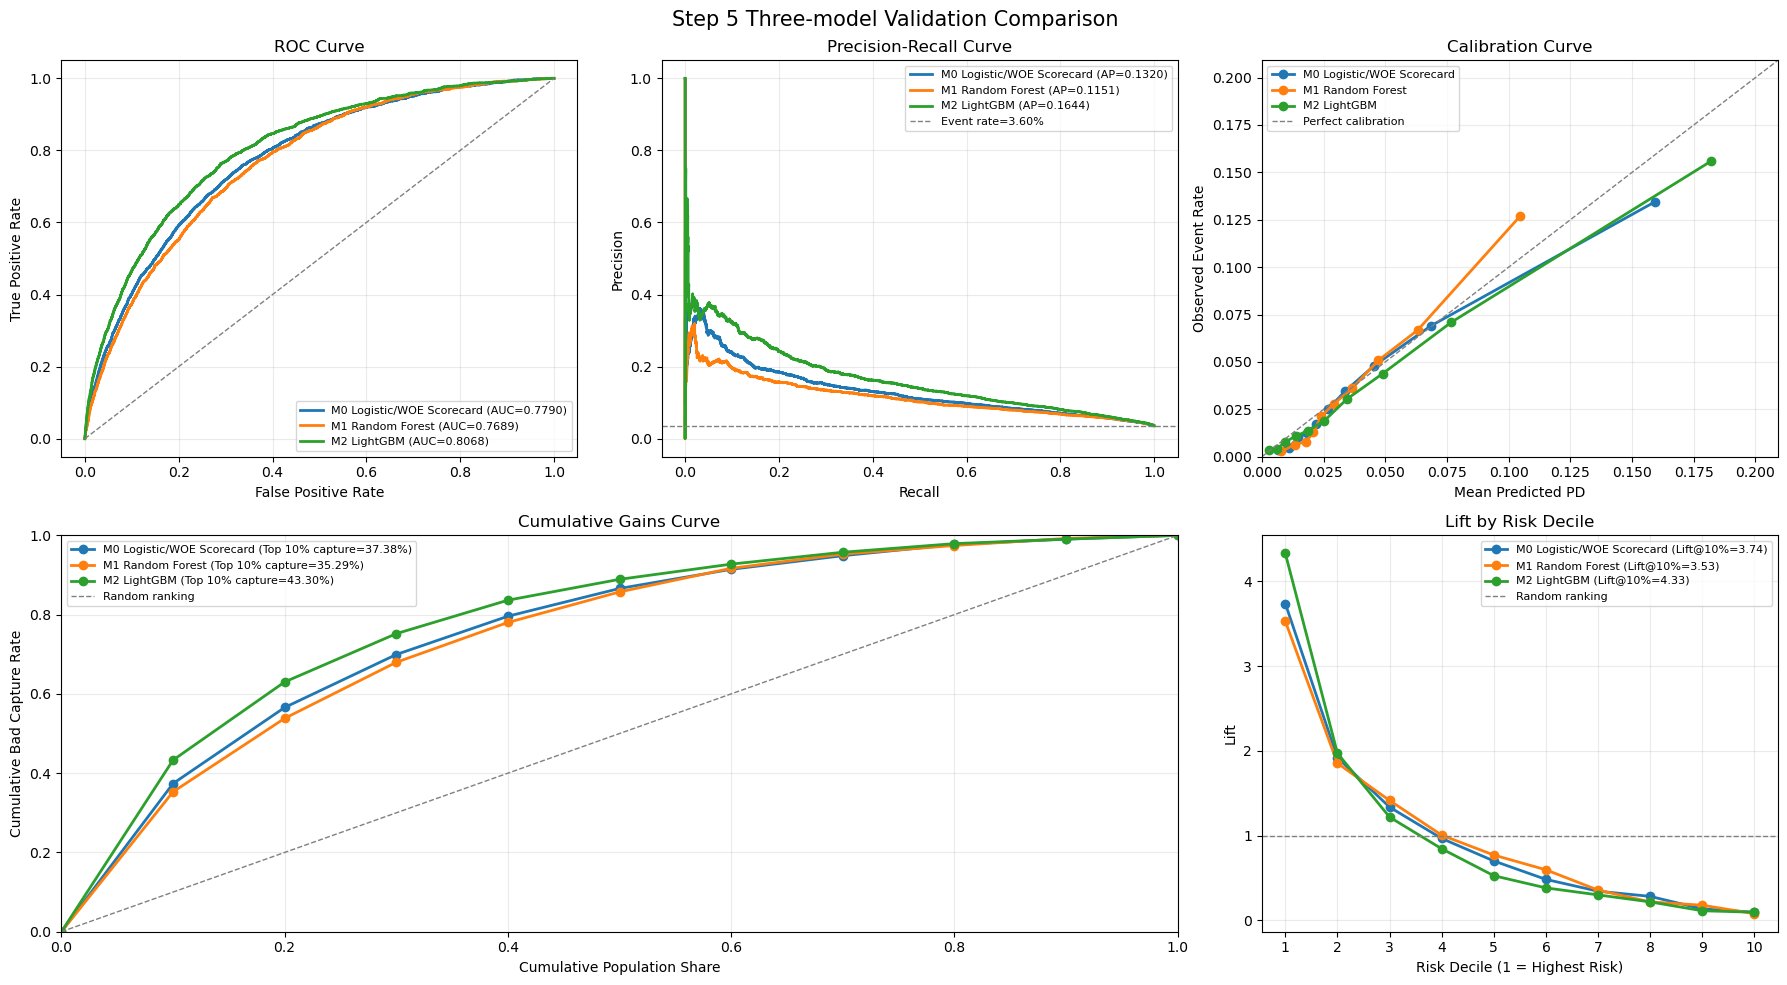


代码块12完成，Step 5完成。
统一评估结果： D:\Risk_control project\outputs\step5\baseline_model_metrics.csv
十等分Lift明细： D:\Risk_control project\outputs\step5\tuning_validation_decile_lift.csv
Validation预测： D:\Risk_control project\outputs\step5\tuning_validation_baseline_predictions.parquet
诊断图： D:\Risk_control project\outputs\step5\baseline_validation_diagnostics.png

Lift@10%定义：最高预测风险约10%样本的坏样本率 ÷ Validation总体坏样本率。
坏样本捕获率定义：最高预测风险约10%样本中的坏样本数 ÷ Validation全部坏样本数。
本步骤未计算PSI；PSI保留到模型冻结后的稳定性分析。
Calibration/Policy Validation和Final OOT仍未读取。


In [22]:
# ============================================================
# 代码块 12｜三模型统一比较、Lift/Gains分析、绘图与保存
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
)


# ------------------------------------------------------------
# 1. 检查必要对象
# ------------------------------------------------------------

required_objects = [
    "PROJECT_ROOT",
    "evaluate_binary_probabilities",
    "y_train",
    "y_validation",
    "validation_case_ids",
    "m0_train_probability",
    "m0_validation_probability",
    "m1_train_probability",
    "m1_validation_probability",
    "m2_train_probability",
    "m2_validation_probability",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "缺少前序代码块对象："
        + ", ".join(missing_objects)
    )


# ------------------------------------------------------------
# 2. 登记三模型预测结果
# ------------------------------------------------------------

model_probability_registry = {
    "M0 Logistic/WOE Scorecard": {
        "model_train": m0_train_probability,
        "tuning_validation": m0_validation_probability,
    },
    "M1 Random Forest": {
        "model_train": m1_train_probability,
        "tuning_validation": m1_validation_probability,
    },
    "M2 LightGBM": {
        "model_train": m2_train_probability,
        "tuning_validation": m2_validation_probability,
    },
}

split_target_registry = {
    "model_train": y_train,
    "tuning_validation": y_validation,
}

model_colors = {
    "M0 Logistic/WOE Scorecard": "#1f77b4",
    "M1 Random Forest": "#ff7f0e",
    "M2 LightGBM": "#2ca02c",
}


# ------------------------------------------------------------
# 3. 使用代码块7的统一评估函数
# ------------------------------------------------------------

def evaluation_to_record(evaluation_result):

    if isinstance(evaluation_result, dict):
        return evaluation_result

    if isinstance(evaluation_result, pd.Series):
        return evaluation_result.to_dict()

    if (
        isinstance(evaluation_result, pd.DataFrame)
        and len(evaluation_result) == 1
    ):
        return evaluation_result.iloc[0].to_dict()

    raise TypeError(
        "评估函数必须返回dict、Series或单行DataFrame。"
    )


evaluation_records = []

for model_name, split_probabilities in (
    model_probability_registry.items()
):

    for split_name, predicted_probability in (
        split_probabilities.items()
    ):

        result = evaluate_binary_probabilities(
            model_name=model_name,
            split_name=split_name,
            y_true=split_target_registry[split_name],
            predicted_probability=predicted_probability,
        )

        evaluation_records.append(
            evaluation_to_record(result)
        )


baseline_evaluation_results = pd.DataFrame(
    evaluation_records
)


# 兼容可能存在的字段命名差异
metric_aliases = {
    "event_rate": "actual_event_rate",
    "auc": "roc_auc",
    "ks_statistic": "ks",
    "average_precision_score": "average_precision",
    "brier": "brier_score",
}

for old_name, standard_name in metric_aliases.items():

    if (
        old_name in baseline_evaluation_results.columns
        and standard_name
        not in baseline_evaluation_results.columns
    ):
        baseline_evaluation_results = (
            baseline_evaluation_results.rename(
                columns={
                    old_name: standard_name
                }
            )
        )


required_metric_columns = {
    "model_name",
    "split_name",
    "sample_count",
    "event_count",
    "actual_event_rate",
    "mean_predicted_pd",
    "pd_minus_event_rate",
    "roc_auc",
    "gini",
    "ks",
    "average_precision",
    "log_loss",
    "brier_score",
}

missing_metric_columns = (
    required_metric_columns
    - set(baseline_evaluation_results.columns)
)

if missing_metric_columns:
    raise ValueError(
        "统一评估函数缺少字段："
        + ", ".join(sorted(missing_metric_columns))
    )


# ------------------------------------------------------------
# 4. 定义统一的十等分Lift/Gains计算函数
#
# 所有模型均按预测PD从高到低排序：
# 第1组 = 预测风险最高的约10%样本
# ------------------------------------------------------------

def build_decile_lift_table(
    y_true,
    predicted_probability,
    number_of_groups=10,
):

    y_array = np.asarray(
        y_true,
        dtype="int8",
    )

    probability_array = np.asarray(
        predicted_probability,
        dtype="float64",
    )

    if len(y_array) != len(probability_array):
        raise ValueError(
            "真实标签与预测概率长度不一致。"
        )

    if len(y_array) == 0:
        raise ValueError("输入样本为空。")

    if not np.isfinite(probability_array).all():
        raise ValueError(
            "预测概率存在NaN或inf。"
        )

    total_sample_count = len(y_array)
    total_event_count = int(y_array.sum())

    if total_event_count == 0:
        raise ValueError(
            "样本中没有坏样本，无法计算Lift。"
        )

    overall_event_rate = (
        total_event_count
        / total_sample_count
    )

    # 稳定降序排列；预测PD越高，风险越高
    descending_order = np.argsort(
        -probability_array,
        kind="mergesort",
    )

    sorted_target = y_array[
        descending_order
    ]

    sorted_probability = probability_array[
        descending_order
    ]

    zero_based_position = np.arange(
        total_sample_count
    )

    risk_decile = (
        np.floor(
            zero_based_position
            * number_of_groups
            / total_sample_count
        )
        .astype("int8")
        + 1
    )

    ranked_data = pd.DataFrame(
        {
            "risk_decile": risk_decile,
            "target": sorted_target,
            "predicted_pd": sorted_probability,
        }
    )

    decile_table = (
        ranked_data
        .groupby(
            "risk_decile",
            as_index=False,
            observed=True,
        )
        .agg(
            sample_count=("target", "size"),
            event_count=("target", "sum"),
            minimum_predicted_pd=(
                "predicted_pd",
                "min",
            ),
            maximum_predicted_pd=(
                "predicted_pd",
                "max",
            ),
            mean_predicted_pd=(
                "predicted_pd",
                "mean",
            ),
        )
    )

    decile_table["event_rate"] = (
        decile_table["event_count"]
        / decile_table["sample_count"]
    )

    decile_table["sample_share"] = (
        decile_table["sample_count"]
        / total_sample_count
    )

    decile_table["event_capture_rate"] = (
        decile_table["event_count"]
        / total_event_count
    )

    decile_table["decile_lift"] = (
        decile_table["event_rate"]
        / overall_event_rate
    )

    decile_table["cumulative_sample_count"] = (
        decile_table["sample_count"].cumsum()
    )

    decile_table["cumulative_event_count"] = (
        decile_table["event_count"].cumsum()
    )

    decile_table[
        "cumulative_population_share"
    ] = (
        decile_table["cumulative_sample_count"]
        / total_sample_count
    )

    decile_table[
        "cumulative_event_capture_rate"
    ] = (
        decile_table["cumulative_event_count"]
        / total_event_count
    )

    decile_table["cumulative_lift"] = (
        decile_table[
            "cumulative_event_capture_rate"
        ]
        / decile_table[
            "cumulative_population_share"
        ]
    )

    top_decile = decile_table.iloc[0]

    lift_summary = {
        "top_10pct_sample_count":
            int(top_decile["sample_count"]),

        "top_10pct_actual_sample_share":
            float(top_decile["sample_share"]),

        "top_10pct_event_count":
            int(top_decile["event_count"]),

        "top_10pct_event_rate":
            float(top_decile["event_rate"]),

        "lift_at_10pct":
            float(top_decile["decile_lift"]),

        "top_10pct_bad_capture_rate":
            float(
                top_decile["event_capture_rate"]
            ),
    }

    return decile_table, lift_summary


# ------------------------------------------------------------
# 5. 计算三模型Validation Lift/Gains
# ------------------------------------------------------------

validation_decile_tables = []
validation_lift_summaries = []

for model_name, split_probabilities in (
    model_probability_registry.items()
):

    decile_table, lift_summary = (
        build_decile_lift_table(
            y_true=y_validation,
            predicted_probability=(
                split_probabilities[
                    "tuning_validation"
                ]
            ),
            number_of_groups=10,
        )
    )

    decile_table.insert(
        0,
        "model_name",
        model_name,
    )

    validation_decile_tables.append(
        decile_table
    )

    validation_lift_summaries.append(
        {
            "model_name": model_name,
            "split_name": "tuning_validation",
            **lift_summary,
        }
    )


validation_decile_lift = pd.concat(
    validation_decile_tables,
    ignore_index=True,
)

validation_lift_summary = pd.DataFrame(
    validation_lift_summaries
)


# 将Lift指标只合并到Validation记录
baseline_evaluation_results = (
    baseline_evaluation_results
    .merge(
        validation_lift_summary,
        on=[
            "model_name",
            "split_name",
        ],
        how="left",
        validate="one_to_one",
    )
)


# ------------------------------------------------------------
# 6. 显示Validation三模型比较
# ------------------------------------------------------------

validation_model_comparison = (
    baseline_evaluation_results
    .loc[
        baseline_evaluation_results["split_name"]
        == "tuning_validation"
    ]
    .sort_values(
        "roc_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

validation_model_comparison.insert(
    0,
    "validation_auc_rank",
    np.arange(
        1,
        len(validation_model_comparison) + 1,
    ),
)

comparison_columns = [
    "validation_auc_rank",
    "model_name",
    "actual_event_rate",
    "mean_predicted_pd",
    "pd_minus_event_rate",
    "roc_auc",
    "gini",
    "ks",
    "average_precision",
    "lift_at_10pct",
    "top_10pct_event_rate",
    "top_10pct_bad_capture_rate",
    "log_loss",
    "brier_score",
]

print("Tuning Validation三模型统一比较：")

display(
    validation_model_comparison[
        comparison_columns
    ].style.format(
        {
            "actual_event_rate": "{:.4%}",
            "mean_predicted_pd": "{:.4%}",
            "pd_minus_event_rate": "{:+.4%}",
            "roc_auc": "{:.6f}",
            "gini": "{:.6f}",
            "ks": "{:.6f}",
            "average_precision": "{:.6f}",
            "lift_at_10pct": "{:.3f}",
            "top_10pct_event_rate": "{:.4%}",
            "top_10pct_bad_capture_rate": "{:.4%}",
            "log_loss": "{:.6f}",
            "brier_score": "{:.6f}",
        }
    )
)


print("\nValidation十等分Lift明细：")

display(
    validation_decile_lift.style.format(
        {
            "minimum_predicted_pd": "{:.6f}",
            "maximum_predicted_pd": "{:.6f}",
            "mean_predicted_pd": "{:.6f}",
            "event_rate": "{:.4%}",
            "sample_share": "{:.4%}",
            "event_capture_rate": "{:.4%}",
            "decile_lift": "{:.3f}",
            "cumulative_population_share": "{:.4%}",
            "cumulative_event_capture_rate": "{:.4%}",
            "cumulative_lift": "{:.3f}",
        }
    )
)


# ------------------------------------------------------------
# 7. Train与Validation排序能力变化
# ------------------------------------------------------------

train_metrics = (
    baseline_evaluation_results
    .loc[
        baseline_evaluation_results["split_name"]
        == "model_train",
        [
            "model_name",
            "roc_auc",
            "ks",
            "average_precision",
        ],
    ]
    .rename(
        columns={
            "roc_auc": "train_roc_auc",
            "ks": "train_ks",
            "average_precision":
                "train_average_precision",
        }
    )
)

validation_metrics = (
    validation_model_comparison[
        [
            "model_name",
            "roc_auc",
            "ks",
            "average_precision",
        ]
    ]
    .rename(
        columns={
            "roc_auc": "validation_roc_auc",
            "ks": "validation_ks",
            "average_precision":
                "validation_average_precision",
        }
    )
)

train_validation_comparison = (
    train_metrics
    .merge(
        validation_metrics,
        on="model_name",
        how="inner",
        validate="one_to_one",
    )
)

train_validation_comparison["roc_auc_drop"] = (
    train_validation_comparison["train_roc_auc"]
    - train_validation_comparison[
        "validation_roc_auc"
    ]
)

train_validation_comparison["ks_drop"] = (
    train_validation_comparison["train_ks"]
    - train_validation_comparison[
        "validation_ks"
    ]
)

print("\nTrain与Validation排序能力变化：")

display(
    train_validation_comparison.style.format(
        {
            "train_roc_auc": "{:.6f}",
            "validation_roc_auc": "{:.6f}",
            "roc_auc_drop": "{:+.6f}",
            "train_ks": "{:.6f}",
            "validation_ks": "{:.6f}",
            "ks_drop": "{:+.6f}",
            "train_average_precision": "{:.6f}",
            "validation_average_precision": "{:.6f}",
        }
    )
)


# ------------------------------------------------------------
# 8. 绘制ROC、PR、校准、Gains和Lift图
# ------------------------------------------------------------

figure, axes = plt.subplot_mosaic(
    [
        ["roc", "pr", "calibration"],
        ["gains", "gains", "lift"],
    ],
    figsize=(18, 10),
)

metric_lookup = (
    validation_model_comparison
    .set_index("model_name")
)

calibration_points = {}


for model_name, split_probabilities in (
    model_probability_registry.items()
):

    validation_probability = (
        split_probabilities[
            "tuning_validation"
        ]
    )

    color = model_colors[model_name]

    # ROC
    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_validation,
            validation_probability,
        )
    )

    axes["roc"].plot(
        false_positive_rate,
        true_positive_rate,
        color=color,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC="
            f"{metric_lookup.loc[model_name, 'roc_auc']:.4f})"
        ),
    )

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(
        y_validation,
        validation_probability,
    )

    axes["pr"].plot(
        recall,
        precision,
        color=color,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AP="
            f"{metric_lookup.loc[model_name, 'average_precision']:.4f})"
        ),
    )

    # Calibration
    observed_rate, mean_probability = (
        calibration_curve(
            y_validation,
            validation_probability,
            n_bins=10,
            strategy="quantile",
        )
    )

    calibration_points[model_name] = (
        mean_probability,
        observed_rate,
    )

    axes["calibration"].plot(
        mean_probability,
        observed_rate,
        marker="o",
        color=color,
        linewidth=2,
        label=model_name,
    )

    # Gains
    model_deciles = (
        validation_decile_lift.loc[
            validation_decile_lift["model_name"]
            == model_name
        ]
        .sort_values("risk_decile")
    )

    gains_x = np.insert(
        model_deciles[
            "cumulative_population_share"
        ].to_numpy(),
        0,
        0.0,
    )

    gains_y = np.insert(
        model_deciles[
            "cumulative_event_capture_rate"
        ].to_numpy(),
        0,
        0.0,
    )

    axes["gains"].plot(
        gains_x,
        gains_y,
        marker="o",
        color=color,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(Top 10% capture="
            f"{metric_lookup.loc[model_name, 'top_10pct_bad_capture_rate']:.2%})"
        ),
    )

    # Decile Lift
    axes["lift"].plot(
        model_deciles["risk_decile"],
        model_deciles["decile_lift"],
        marker="o",
        color=color,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(Lift@10%="
            f"{metric_lookup.loc[model_name, 'lift_at_10pct']:.2f})"
        ),
    )


# ROC设置
axes["roc"].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    linewidth=1,
)

axes["roc"].set_title("ROC Curve")
axes["roc"].set_xlabel("False Positive Rate")
axes["roc"].set_ylabel("True Positive Rate")
axes["roc"].legend(fontsize=8)
axes["roc"].grid(alpha=0.25)


# PR设置
validation_event_rate = float(
    np.mean(y_validation)
)

axes["pr"].axhline(
    validation_event_rate,
    linestyle="--",
    color="grey",
    linewidth=1,
    label=(
        f"Event rate={validation_event_rate:.2%}"
    ),
)

axes["pr"].set_title("Precision-Recall Curve")
axes["pr"].set_xlabel("Recall")
axes["pr"].set_ylabel("Precision")
axes["pr"].legend(fontsize=8)
axes["pr"].grid(alpha=0.25)


# Calibration设置
calibration_maximum = max(
    max(
        float(np.max(mean_probability)),
        float(np.max(observed_rate)),
    )
    for mean_probability, observed_rate
    in calibration_points.values()
)

calibration_axis_maximum = min(
    max(calibration_maximum * 1.15, 0.05),
    1.0,
)

axes["calibration"].plot(
    [0, calibration_axis_maximum],
    [0, calibration_axis_maximum],
    linestyle="--",
    color="grey",
    linewidth=1,
    label="Perfect calibration",
)

axes["calibration"].set_xlim(
    0,
    calibration_axis_maximum,
)

axes["calibration"].set_ylim(
    0,
    calibration_axis_maximum,
)

axes["calibration"].set_title(
    "Calibration Curve"
)

axes["calibration"].set_xlabel(
    "Mean Predicted PD"
)

axes["calibration"].set_ylabel(
    "Observed Event Rate"
)

axes["calibration"].legend(fontsize=8)
axes["calibration"].grid(alpha=0.25)


# Gains设置
axes["gains"].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    linewidth=1,
    label="Random ranking",
)

axes["gains"].set_title(
    "Cumulative Gains Curve"
)

axes["gains"].set_xlabel(
    "Cumulative Population Share"
)

axes["gains"].set_ylabel(
    "Cumulative Bad Capture Rate"
)

axes["gains"].set_xlim(0, 1)
axes["gains"].set_ylim(0, 1)
axes["gains"].legend(fontsize=8)
axes["gains"].grid(alpha=0.25)


# Lift设置
axes["lift"].axhline(
    1.0,
    linestyle="--",
    color="grey",
    linewidth=1,
    label="Random ranking",
)

axes["lift"].set_title(
    "Lift by Risk Decile"
)

axes["lift"].set_xlabel(
    "Risk Decile (1 = Highest Risk)"
)

axes["lift"].set_ylabel("Lift")
axes["lift"].set_xticks(range(1, 11))
axes["lift"].legend(fontsize=8)
axes["lift"].grid(alpha=0.25)


figure.suptitle(
    "Step 5 Three-model Validation Comparison",
    fontsize=15,
)

figure.tight_layout()


# ------------------------------------------------------------
# 9. 保存精简结果
# ------------------------------------------------------------

STEP5_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "step5"
)

STEP5_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METRICS_OUTPUT_PATH = (
    STEP5_OUTPUT_DIR
    / "baseline_model_metrics.csv"
)

DECILE_OUTPUT_PATH = (
    STEP5_OUTPUT_DIR
    / "tuning_validation_decile_lift.csv"
)

PREDICTIONS_OUTPUT_PATH = (
    STEP5_OUTPUT_DIR
    / "tuning_validation_baseline_predictions.parquet"
)

FIGURE_OUTPUT_PATH = (
    STEP5_OUTPUT_DIR
    / "baseline_validation_diagnostics.png"
)


baseline_evaluation_results.to_csv(
    METRICS_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
    float_format="%.8f",
)

validation_decile_lift.to_csv(
    DECILE_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
    float_format="%.8f",
)

validation_prediction_output = pd.DataFrame(
    {
        "case_id": np.asarray(
            validation_case_ids
        ),
        "target": np.asarray(
            y_validation,
            dtype="int8",
        ),
        "m0_scorecard_pd": np.asarray(
            m0_validation_probability,
            dtype="float32",
        ),
        "m1_random_forest_pd": np.asarray(
            m1_validation_probability,
            dtype="float32",
        ),
        "m2_lightgbm_pd": np.asarray(
            m2_validation_probability,
            dtype="float32",
        ),
    }
)

validation_prediction_output.to_parquet(
    PREDICTIONS_OUTPUT_PATH,
    index=False,
)

figure.savefig(
    FIGURE_OUTPUT_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 10. 完成信息
# ------------------------------------------------------------

print("\n代码块12完成，Step 5完成。")
print("统一评估结果：", METRICS_OUTPUT_PATH)
print("十等分Lift明细：", DECILE_OUTPUT_PATH)
print("Validation预测：", PREDICTIONS_OUTPUT_PATH)
print("诊断图：", FIGURE_OUTPUT_PATH)

print(
    "\nLift@10%定义："
    "最高预测风险约10%样本的坏样本率"
    " ÷ Validation总体坏样本率。"
)

print(
    "坏样本捕获率定义："
    "最高预测风险约10%样本中的坏样本数"
    " ÷ Validation全部坏样本数。"
)

print(
    "本步骤未计算PSI；"
    "PSI保留到模型冻结后的稳定性分析。"
)

print(
    "Calibration/Policy Validation和Final OOT"
    "仍未读取。"
)